# Notebook 3: Data Cleaning Pipeline 

**Structure in this version:** every phase is split into two clearly separated parts:

1. **Findings** - read-only. Shows you what's in the data. Changes nothing.
2. **Changes** - only runs after you've seen the findings and confirmed what to do with them. This is where data actually gets modified.

This means you always see the diagnosis before the treatment, and can add to the 'changes' step based on what the 'findings' step showed you, before running it.


# Phase 0 - Setup & Type Conversion

Load the data, technical text cleanup (whitespace, lowercase), convert each column to its correct type per your mapping (date / number / text), and build `target_binary`. 

If a date parser fails to interpret a value, it stays NaN (missing) - it is never filled with 0 or any other default. No column is dropped in this phase.


In [42]:
# Imports and display settings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple
import re
import json
import unicodedata
import warnings
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 240)

RANDOM_STATE = 42


def show(title: str, obj=None) -> None:
    """INFO: Prints a one-line explanation before showing a table, so every table is self-explanatory."""
    print(f"\n>>> {title}")
    if obj is not None:
        display(obj)


In [43]:
# ------------------------------------------------------------------
# OFFLINE ICD-9-CM DICTIONARY
# ------------------------------------------------------------------
# the path for the ICD-9 dictionary JSON file
ICD9_DICTIONARY_PATH = Path(r"H:\27 project\cleaning\cleaning_new\icd9_surgical_dictionary.json")


def load_icd9_dictionary(path: Path = ICD9_DICTIONARY_PATH) -> Dict:
    if not path.exists():
        raise FileNotFoundError(
            f"ICD9 dictionary not found: {path}\n"
            "Copy icd9_surgical_dictionary.json to this path (or edit ICD9_DICTIONARY_PATH)."
        )
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_icd9_code(value, kind: str) -> str:
    """
    Normalize ICD-9 codes while preserving leading-zero semantics.
    - diagnosis numeric codes use 3 digits before the decimal when needed
      (e.g. 38.9 -> 038.9)
    - procedure codes use 2 digits before the decimal when needed
      (e.g. 3.09 -> 03.09)
    V/E diagnosis codes are preserved.
    """
    if pd.isna(value):
        return ""

    s = str(value).strip().upper()
    if not s or s in {"NAN", "NONE", "<NA>"}:
        return ""

    # Remove trailing .0 introduced by Excel/pandas only when it represents an integer.
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]

    s = s.replace(" ", "")

    if s.startswith(("V", "E")):
        return s

    if re.fullmatch(r"\d+(?:\.\d+)?", s):
        left, dot, right = s.partition(".")
        width = 3 if kind == "diagnosis" else 2
        left = left.zfill(width)
        return left + (dot + right if dot else "")

    return s


def normalize_clinical_text(value) -> str:
    if pd.isna(value):
        return ""
    s = str(value).lower().strip()
    s = re.sub(r"[\t\r\n]+", " ", s)
    s = re.sub(r"[^0-9a-zA-Z\u0590-\u05FF]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


In [ ]:
# Project cleaning configuration

# INPUT / OUTPUT
DATA_PATH = Path(r"H:\27 project\EDA\Copy of Dataset Zihum Raw.xlsx")
MAPPING_PATH: Optional[Path] = Path(r"H:\27 project\EDA\correct_mapping_columns.xlsx")
OUTPUT_DIR = Path(r"H:\27 project\cleaning\cleaning_outputs")
SAVE_OUTPUTS = True

# CORE PROJECT DEFINITIONS
TARGET_COL = "target_binary"

# --- PREDICTION WINDOW ---
# Event-based, not a fixed clock offset from admission: everything from pre-op through the END of surgery, 
# including the surgery duration itself, recovery and the immediate post-op physician summary written
# right after surgery (description_surgical_procedure). 
# No extended post-surgery monitoring window.

# PREDICTION_CUTOFF_HOURS is kept only so existing f-strings / the audit function below still run without further edits. 
# It is not a clock offset from admission- treat it as "0 hours past surgery end".
PREDICTION_CUTOFF_HOURS = 0
RECOVERY_TOLERANCE_CAP_HOURS: float = 6.0

# Values that truly represent missing text, not a clinical negative result.
EXPLICIT_MISSING_TOKENS = {
    "", " ", "na", "n/a", "nan", "none", "null", "missing",
    "Nan", "NaN", "N/A", "NULL", "חסר", "אין נתון", "-",
}

# Single canonical name per column - resolve_column() already matches case/spacing/
# hyphen variants internally, and raw columns are already lowercase_with_underscores.
SURGERY_DATE_CANDIDATES = ["activity_date"]
ADMISSION_DATE_CANDIDATES = ["admission_date"]
DISCHARGE_DATE_CANDIDATES = ["discharge_date"]
CASE_ID_CANDIDATES = ["case_number"]

NLP_TEXT_CANDIDATES = {
    "disease_history": ["first_hospitalization_disease_history"],
    "surgical_procedure": ["description_surgical_procedure"],
}

INFECTION_SOURCE_CANDIDATES = {
    "infection_diagnosis": ["added1_infection_diagnosis"],
    "clinical_ssi": ["clinical_SSI_diagnosis"],
}

# Free-text NLP narrative columns keep their original casing — case carries real
# information here (sentence starts, proper nouns, abbreviations like "IV"/"PO").
NO_LOWERCASE_COLS = [
    "first_hospitalization_disease_history",
    "description_surgical_procedure",
]


## General helper functions and robust column resolution


In [45]:
def _canonical_key(value: Any) -> str:
    """INFO: Canonical representation used only for safe name matching."""
    text = unicodedata.normalize("NFKC", str(value))
    text = text.strip().lower()
    text = re.sub(r"[_\-/]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text


def normalise_column_names(columns: Iterable[Any]) -> pd.Index:
    """INFO: Preserve original names while removing leading/trailing/repeated whitespace only."""
    return (
        pd.Index(columns)
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def _is_text_like(series: pd.Series) -> bool:
    return pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)


def resolve_column(
    df_input: pd.DataFrame,
    candidates: Sequence[str],
    required: bool = False,
    human_name: str = "",
) -> Optional[str]:
    """INFO: Resolve spaces/underscores/hyphens without silently guessing a different variable."""
    exact_map = {str(c): str(c) for c in df_input.columns}
    canonical_map: Dict[str, List[str]] = {}
    for col in df_input.columns:
        canonical_map.setdefault(_canonical_key(col), []).append(str(col))

    for candidate in candidates:
        if candidate in exact_map:
            return candidate

    for candidate in candidates:
        matches = canonical_map.get(_canonical_key(candidate), [])
        if len(matches) == 1:
            return matches[0]
        if len(matches) > 1:
            raise ValueError(
                f"Ambiguous match for {human_name or candidate}: {matches}. "
                "Resolve manually rather than choosing silently."
            )

    if required:
        raise KeyError(
            f"Could not resolve required column '{human_name or candidates[0]}'. "
            f"Tried: {list(candidates)}"
        )
    return None


def build_infection_label(
    df, diagnosis_col="added1_infection_diagnosis", site_col="clinical_SSI_diagnosis", target_col="target_binary",
):
    """
    Returns the complete df with a new boolian column: "Target" (0/1).
    There are rows where the 'infection' column is empty but the 'infection_site' is not and vice versa.
    We define that a patient with a positive diagnosis is one that have at least on of these two rows that is not empty.
    """
    diag_present = (df[diagnosis_col].fillna("").astype(str).str.strip().ne(""))
    site_present = (df[site_col].fillna("").astype(str).str.strip().ne(""))
    df[target_col] = (diag_present | site_present).astype(int)
    return df


def make_output_folders(base_dir: Path) -> Dict[str, Path]:
    """
    INFO:
    Two folders - that's all this notebook produces:
    - "01_audit": one Excel workbook, one sheet per diagnostic/QA table built throughout this notebook 
      (storage cleaning stats, leakage list, outlier clipping, missingness, chronology, near-duplicates, 
      noise-reduction log, etc). For YOUR review - never read back into the pipeline.
    - "02_cleaned_data": the actual cleaned dataset itself, as one CSV.
    """
    folders = {"base": base_dir, "audit": base_dir / "01_audit", "clean": base_dir / "02_cleaned_data"}
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


## `clean_text_storage` - storage-level cleaning, lowercase-aware


In [46]:
def clean_text_storage(series: pd.Series, apply_lowercase: bool = True) -> Tuple[pd.Series, Dict[str, int]]:
    """
    INFO:
    Storage-level text cleaning only:
    - strip leading/trailing whitespace
    - collapse repeated whitespace
    - lowercase (unless apply_lowercase=False — used for free-text NLP narrative columns)
    - convert explicit missing tokens to true missing values
    No stemming, stop-word removal, or semantic rewriting is performed.
    """
    if not _is_text_like(series):
        return series, {"trimmed_or_collapsed": 0, "lowercased": 0, "tokens_to_missing": 0}

    original = series.copy()
    cleaned = series.astype("string")
    cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()

    lowercased_mask = pd.Series(False, index=cleaned.index)
    if apply_lowercase:
        pre_lower = cleaned.copy()
        cleaned = cleaned.str.lower()
        lowercased_mask = pre_lower.notna() & cleaned.notna() & pre_lower.ne(cleaned)

    token_set = {_canonical_key(x) for x in EXPLICIT_MISSING_TOKENS}
    token_mask = cleaned.map(lambda x: _canonical_key(x) in token_set if pd.notna(x) else False)

    changed_mask = original.notna() & cleaned.notna() & original.astype(str).ne(cleaned.astype(str))
    cleaned = cleaned.mask(token_mask)

    return cleaned, {
        "trimmed_or_collapsed": int(changed_mask.sum()),
        "lowercased": int(lowercased_mask.sum()),
        "tokens_to_missing": int(token_mask.sum()),
    }


def apply_storage_cleaning(df_input: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """INFO: Run clean_text_storage over every text-like column, skipping lowercase for NLP narrative columns."""
    result = df_input.copy()
    rows = []
    for col in result.columns:
        if not _is_text_like(result[col]):
            continue
        cleaned, stats = clean_text_storage(result[col], apply_lowercase=col not in NO_LOWERCASE_COLS)
        result[col] = cleaned
        rows.append({"action": "text_storage_cleaning", "column": col, **stats})
    return result, pd.DataFrame(rows)


## Datetime parsing and semantic type conversion


In [47]:
def robust_datetime_conversion(series: pd.Series) -> Tuple[pd.Series, Dict[str, Any]]:
    """
    INFO:
    Parse mixed Assuta date storage safely.
    Supported sources: existing pandas datetime, Excel serial dates (origin 1899-12-30), YYYYMMDD numeric values, normal date strings.
    For plain text dates, uses Israeli day-first parsing (DD/MM/YYYY) FIRST, then retries only still-failed values without dayfirst. 
    This makes ambiguous values such as 03/04/2025 resolve as 3 April 2025 rather than 4 March 2025, while preserving support 
    for other parseable date representations.
    Numeric values that do not match a supported date representation are NOT interpreted as nanoseconds since 1970; 
    they remain NaT and are reported.
    """
    raw = series.copy()
    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    if pd.api.types.is_datetime64_any_dtype(series):
        parsed = pd.to_datetime(series, errors="coerce")
        return parsed, {
            "non_missing_before": int(series.notna().sum()),
            "non_missing_after": int(parsed.notna().sum()),
            "excel_serial_rows": 0, "yyyymmdd_rows": 0,
            "parse_failures": int((series.notna() & parsed.isna()).sum()),
            "failure_examples": [],
        }

    numeric = pd.to_numeric(series, errors="coerce")

    excel_mask = series.notna() & numeric.between(20000, 80000)
    if excel_mask.any():
        result.loc[excel_mask] = pd.to_datetime(
            numeric.loc[excel_mask], unit="D", origin="1899-12-30", errors="coerce",
        )

    ymd_mask = (
        series.notna() & ~excel_mask
        & numeric.between(19000101, 21001231) & numeric.mod(1).eq(0)
    )
    if ymd_mask.any():
        result.loc[ymd_mask] = pd.to_datetime(
            numeric.loc[ymd_mask].astype("Int64").astype(str), format="%Y%m%d", errors="coerce",
        )

    remaining = series.notna() & ~excel_mask & ~ymd_mask
    if remaining.any():
        text_values = series.loc[remaining].astype("string").str.strip()

        # Israeli hospital data: DD/MM/YYYY gets explicit priority.
        # This prevents ambiguous dates such as 03/04/2025 from being silently
        # interpreted as March 4 instead of 3 April.
        parsed = pd.to_datetime(text_values, errors="coerce", dayfirst=True)

        # Retry only values that still failed. This keeps support for unusual
        # non-Israeli / ISO-like strings without overriding a valid DD/MM parse.
        still_failed = parsed.isna()
        if still_failed.any():
            parsed.loc[still_failed] = pd.to_datetime(
                text_values.loc[still_failed], errors="coerce", dayfirst=False,
            )
        result.loc[remaining] = parsed

    failure_mask = series.notna() & result.isna()
    examples = series.loc[failure_mask].astype(str).drop_duplicates().head(8).tolist()

    return result, {
        "non_missing_before": int(series.notna().sum()),
        "non_missing_after": int(result.notna().sum()),
        "excel_serial_rows": int(excel_mask.sum()),
        "yyyymmdd_rows": int(ymd_mask.sum()),
        "parse_failures": int(failure_mask.sum()),
        "failure_examples": examples,
    }


def load_semantic_mapping(path: Optional[Path]) -> pd.DataFrame:
    """INFO: Load the reviewed EDA mapping as-is. Fails fast only on the basics."""
    if path is None or not path.exists():
        raise FileNotFoundError(f"Semantic mapping file not found at '{path}'.")
    mapping = pd.read_excel(path)
    if "Column_name" not in mapping.columns or "Column_type" not in mapping.columns:
        raise ValueError(
            f"Mapping file '{path}' is missing 'Column_name' / 'Column_type' "
            f"(found: {list(mapping.columns)})."
        )
    mapping["Column_name"] = normalise_column_names(mapping["Column_name"])
    return mapping


def convert_semantic_types(df_input: pd.DataFrame, mapping_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    INFO:
    Direct membership check against the mapping's own lists — no name-based guessing for
    ANY type. Datetime -> robust_datetime_conversion. Numeric -> pd.to_numeric (coerce).
    Categorical/Text/Boolean -> kept as clean text (Boolean is NOT forced to 0/1 — it
    stays text and gets one-hot-encoded later, like any other categorical column).
    TARGET_COL is force-numeric regardless of what the mapping says.
    """
    result = df_input.copy()
    datetime_cols = mapping_df[mapping_df["Column_type"] == "Datetime"]["Column_name"].tolist()
    numeric_cols = mapping_df[mapping_df["Column_type"] == "Numeric"]["Column_name"].tolist()
    text_like_cols = mapping_df[mapping_df["Column_type"].isin(["Categorical", "Text", "Boolean"])]["Column_name"].tolist()

    audit_rows = []
    for col in result.columns:
        if col in datetime_cols:
            converted, audit = robust_datetime_conversion(result[col])
            result[col] = converted
            audit_rows.append({"column": col, "requested_type": "Datetime", **audit})
        elif col in numeric_cols:
            before = result[col]
            numeric = pd.to_numeric(before, errors="coerce")
            failures = before.notna() & numeric.isna()
            result[col] = numeric
            audit_rows.append({
                "column": col, "requested_type": "Numeric",
                "non_missing_before": int(before.notna().sum()),
                "non_missing_after": int(numeric.notna().sum()),
                "parse_failures": int(failures.sum()),
                "failure_examples": before.loc[failures].astype(str).drop_duplicates().head(8).tolist(),
            })
        elif col in text_like_cols:
            result[col] = result[col].astype("string")

    if TARGET_COL in result.columns:
        result[TARGET_COL] = pd.to_numeric(result[TARGET_COL], errors="coerce")

    audit_df = pd.DataFrame(audit_rows)
    if not audit_df.empty:
        audit_df["failure_rate_percent"] = np.where(
            audit_df["non_missing_before"] > 0,
            100 * audit_df["parse_failures"] / audit_df["non_missing_before"],
            0.0,
        ).round(2)
        high_failure = audit_df[
            (audit_df["non_missing_before"] > 0) & (audit_df["failure_rate_percent"] >= 50)
        ].sort_values("failure_rate_percent", ascending=False)
        if not high_failure.empty:
            print(f"WARNING: {len(high_failure)} column(s) lost 50%+ of their non-missing values:")
            for _, row in high_failure.iterrows():
                print(f"  - {row['column']!r} ({row['requested_type']}): {row['failure_rate_percent']:.1f}% failed")
    return result, audit_df


## Phase 0 - execution: load data, apply mapping, convert types, build target


In [ ]:
print("Loading data...")
df_raw = pd.read_excel(DATA_PATH)
df_raw.columns = normalise_column_names(df_raw.columns)

# Explicit safety copy - everything from here on operates on `working`, a separate object. 
# df_raw itself is never touched again, so even if a bug somewhere mutated a DataFrame in place, 
# it could never reach back into the original loaded data.
working = df_raw.copy(deep=True)

print("Loading semantic mapping...")
mapping_df = load_semantic_mapping(MAPPING_PATH)

print("\nApplying storage-level text cleaning (whitespace, lowercase, missing tokens)...")
working, storage_cleaning_audit = apply_storage_cleaning(working)

print("\nConverting types based on mapping...")
working, type_conversion_audit = convert_semantic_types(working, mapping_df)

print("\nBuilding target_binary...")
_diag_col = resolve_column(working, INFECTION_SOURCE_CANDIDATES["infection_diagnosis"], required=True, human_name="infection diagnosis source")
_ssi_col = resolve_column(working, INFECTION_SOURCE_CANDIDATES["clinical_ssi"], required=True, human_name="clinical SSI diagnosis source")
working = build_infection_label(working, diagnosis_col=_diag_col, site_col=_ssi_col, target_col=TARGET_COL)
print(f"target_binary built: {int(working[TARGET_COL].sum())} positive / {len(working)} total.")

# --- Sanity checks in place of the full case_id/duplicate audit ---
case_id_col = resolve_column(working, CASE_ID_CANDIDATES, required=True, human_name="case identifier")
assert working[TARGET_COL].isin([0, 1]).all(), f"{TARGET_COL} contains values outside {{0,1}}"
assert working[case_id_col].notna().all(), f"{case_id_col} has missing values"

print(f"\nPhase 0 complete. Rows: {len(working)}, Columns: {working.shape[1]}")


Loading data...
Loading semantic mapping...

Applying storage-level text cleaning (whitespace, lowercase, missing tokens)...

Converting types based on mapping...
  - 'urine_culture_3_date' (Datetime): 100.0% failed

Building target_binary...
target_binary built: 141 positive / 35925 total.

Phase 0 complete. Rows: 35925, Columns: 244


### Cohort reduction

In [49]:
# Searching for activity clusters without any infection case. The patients in those clusters will be removed from our cohort.
_candidate_cluster_counts = working.groupby("activity_cluster", dropna=False)[TARGET_COL].agg(
        n_rows="size", n_infections="sum",
    )
_candidate_zero_infection_clusters = (
    _candidate_cluster_counts.loc[_candidate_cluster_counts["n_infections"] == 0]
    .sort_values("n_rows", ascending=False)
)

print(f"Candidate activity_cluster values with 0 observed infections "
        f"(n={len(_candidate_zero_infection_clusters)}):")
display(_candidate_zero_infection_clusters)


Candidate activity_cluster values with 0 observed infections (n=4):


,n_rows,n_infections
activity_cluster,,
אף אוזן וגרון,433,0
נוירוכירורגיה,44,0
פלסטיקה,9,0
רדיוכירורגיה,2,0


In [50]:
# Final study cohort restriction

AGE_MIN = 28 
EXCLUDED_ACTIVITY_CLUSTERS: List[str] = [
    "אף אוזן גרון",
    "נוירוכירורגיה",
    "פלסטיקה", 
    "רדיוכירורגיה"
]

#_working_before_cohort = working.copy()

_cohort_mask = (
    (pd.to_numeric(working["age"], errors="coerce") < AGE_MIN)
    | (working["activity_cluster"].isin(EXCLUDED_ACTIVITY_CLUSTERS))
)

_n_before = len(working)
working = working.loc[~_cohort_mask].reset_index(drop = True)
print(f"Final study cohort restriction: {_n_before} -> {len(working)} rows "
      f"{_n_before - len(working)} removed")


Final study cohort restriction: 35925 -> 31849 rows 4076 removed


In [51]:
# If we want to look the cohort dataset before leakage removing 

# _cohort_restricted_export_path = OUTPUT_DIR / "cohort_restricted.xlsx"
# working.to_excel(_cohort_restricted_export_path, index=False, engine="openpyxl")
# print(f"Saved cohort-restricted table: {_cohort_restricted_export_path} ({len(working)} rows)")

### Leakage and prediction-window enforcement

Columns that are only ever populated **after** the prediction windoware removed here , before any other cleaning decision. Two mechanisms:

- **Unconditional lekage** ('LEAKAGE_COLS_TO_DROP') - columns that are always post-window (cultures, antibiotics >36h...) are drop entirely, with no exceptions.
- **Empirical timing gate** ('TIMING_GATED_COLUMN_GROUPS') - columns whose timing varies by patient (CVC, catheter, first labs) are checked per row against the window: if 70%+ of values fall inside it, only the out-of-window values become missing; otherwise the whole group is dropped.

Nothing here is a feature engineering decision - it only answers whether a value is **alowed to exist** at prediction time, not how it should be representsd as a feature.

In [ ]:
# ============================================================
# TIER A - CONFIDENT LEAKAGE (drop unconditionally)
# ============================================================
LEAKAGE_COLS_TO_DROP: List[str] = [
    # --- Target source columns --- 
    "added1_infection diagnosis", "clinical SSI diagnosis",

    # --- Cultures ---
    "blood_culture_1_result", "blood_culture_1_test_date", "blood_culture_1_test_panel", "blood_culture_1_organism_detected",
    "blood_culture_2_result", "blood_culture_2_result.1", "blood_culture_2_test_date", "blood_culture_2_test_panel", "blood_culture_2_organism_detected",
    "blood_culture_3_result", "blood_culture_3_test_date", "blood_culture_3_test_panel", "blood_culture_3_organism_detected",
    "blood_culture_4_result", "blood_culture_4_test_date", "blood_culture_4_test_panel", "blood_culture_4_organism_detected",
    "blood_culture_5_result", "blood_culture_5_test_date", "blood_culture_5_test_panel", "blood_culture_5_organism_detected",
    "blood_culture_6_result", "blood_culture_6_test_date", "blood_culture_6_test_panel", "blood_culture_6_organism_detected",
    "urine_culture_1_result", "urine_culture_1_date", "urine_culture_1_organism detected",
    "urine_culture_2_result", "urine_culture_2_date", "urine_culture_2_organism_detected",
    "urine_culture_3_result", "urine_culture_3_test", "urine_culture_3_organism_detected", "urine_culture_3_date",
    "urine_culture_4_result", "urine_culture_4_date", "urine_culture_4_organism_detected",
    "urine_culture_5_result", "urine_culture_5_date", "urine_culture_5_organism_detected",
    "urine_culture_6_result", "urine_culture_6_date", "urine_culture_6_organism_detected",
    "added1_blood_and/or_wound_cultures_taken_2-90_days_post_surgery",
    "added1_wound_culture_organism_detected", "added1_wound_culture_specimen_source", "added1_wound_culture_result",
    "added1_culture_result_organism", "added1_culture_result_test_date", "added1_wound_culture_test",
    # detected_pathogen / added1_detected_pathogen_specimen_source: this is PREOP
    # pathogen screening (e.g. E. coli carriage screening before surgery), so not leakage.


    # --- Medications given "36 hours after admission" ---
    "antibiotics_given_more_than_36_hours_after_admission_drug_name",
    "antibiotics_given_more_than_36_hours_after_admission_drug_quantity",
    "antibiotics_given_more_than_36_hours_after_admission_drug_route",
    "antibiotics_given_more_than_36_hours_after_admission_drug_unit",
    "iv_analgesics_given_more_than_36_hours_after_admission_drug_name",
    "iv_analgesics_given_more_than_36_hours_after_admission_drug_quantity",
    "iv_analgesics_given_more_than_36_hours_after_admission_drug_route",
    "iv_analgesics_given_more_than_36_hours_after_admission_drug_unit",
    "diuretics_give_after_36_hours_from_admission_name",
    "diuretics_give_after_36_hours_from_admission_quantity",
    "diuretics_give_after_36_hours_from_admission_route",
    "diuretics_give_after_36_hours_from_admission_unit",
    "ppi_give_after_36_hours_from_admission_name",
    "ppi_give_after_36_hours_from_admission_quantity",
    "ppi_give_after_36_hours_from_admission_route",
    "ppi_give_after_36_hours_from_admission_unit",

    # --- Catheter / drain removal ---
    # TPN,CVC and catheter timing is checked empirically rather than assumed - see
    # TIMING_GATED_COLUMN_GROUPS below (gated on tpn_start_date), not listed here.
 
    # Drain presence ("added1_drain_left_in_place_clean_from_surgery") is RETAINED:
    # EDA/clinical interpretation indicates that leaving a surgical drain is an
    # intra-operative decision and may represent surgical complexity.
    "added1_drain_left_in_place_end_date",

    # --- Revision diagnosis during THIS hospitalization ---
    # Can only be known once the hospitalization is already underway after the surgical event - 
    # not knowable at "end of surgery" - unconditional leakage as a MODEL FEATURE. 
    "revision_diagnoses_during_hosp", "revision_diagnoses_during_hosp_session_date", "additional_surgery_bed",
    "additional_surgery_during_hosp_transfer_start_date", "additional_surgery_during_hosp_transfer_end_date",


    # --- Readmission (entirely post-discharge, future events) ---
    "readmission_activity_date", "readmission_admission_date_days_from_reference", "readmission_actual_activity",
    "readmission_activity_cluster", "readmission_case_number", "readmission_hospital", "readmission_length_of_stay",
    "readmission_surgeon_code", "readmission_surgeon_specialization", "readmission_department",
    "readmission_cause_value", "main_complaint_readmission_value", "added1_readmission_within_100_days_after_surgery",

    # --- Discharge and end_dates ---
    "discharge_date", "discharge_weekday", "discharge_destination", "icu_transfer_end_date",

    # --- Late post-surgery values ---
    "added1_post_surgery_glucose_level_result_numeric", "added1_day_2_post_surgery_glucose_level_result_numeric",
    "added1_wound_assessment_str_value", "first_evaluation_postop_in_days", "description_first_evaluation_postop",
    "length_of_stay_hrs",

    # --- "Last" values ---
    "lab_hemoglobin_last_date", "lab_hemoglobin_last_value_g/dL",
    "lab_crp_last_date", "lab_crp_last_value_mg/L",
    "lab_creatinine_last_date", "lab_creatinine_last_value_mg/dL",
    "lab_glucose_last_date", "lab_glucose_last_value_mg/dL",
    "lab_plt_last_date", "lab_plt_last_value_10^3/µL",
    "lab_k_last_date", "lab_k_last_value_mmol/L",
    "lab_procalcitonin_last_date", "lab_procalcitonin_last_value_ng/ml",
    "lab_na_last_date", "lab_na_last_value_mmol/L",
    "lab_wbc_last_date", "lab_wbc_last_value",
    "median_heart_rate_last_24_hour_value",
    "max_heart_rate_last_24_hour_value",
    "median_systolic_BP_last_24_hours_value",
    "median_diastolic_BP_last_24_hours_value"
]


In [ ]:
def apply_leakage_pruning(df_input: pd.DataFrame, cols_to_drop: List[str] = LEAKAGE_COLS_TO_DROP) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """INFO: Drop only columns explicitly listed in cols_to_drop."""
    resolved_to_drop, rows = [], []
    for name in cols_to_drop:
        resolved = resolve_column(df_input, [name], required=False)
        if resolved:
            resolved_to_drop.append(resolved)
            rows.append({"column": name, "status": "dropped"})
        else:
            rows.append({"column": name, "status": "not_found"})
    result = df_input.drop(columns=resolved_to_drop, errors="ignore")
    print(f"Dropped {len(resolved_to_drop)} / {len(cols_to_drop)} confirmed-leakage columns.")
    return result, pd.DataFrame(rows)


# ============================================================
# TIMING-GATED COLUMNS - empirical date-difference rule
# ============================================================
# General rule you specified: for any column whose validity depends on WHEN it was recorded relative to surgery, 
# compute the time difference to the end of surgery. If FEWER than TIMING_AUDIT_MIN_COMPLIANT_FRACTION (70%) of 
# the non-missing values fall inside the allowed window, the column (and its companions) is dropped ENTIRELY - 
# it's not worth keeping a mostly-out-of-window column. Otherwise, only the individual out-of-window VALUES become NaN 
# (same pattern as PHYSIOLOGICAL_BOUNDS), and the column is kept.

# "End of surgery" = activity_date + added1_length_of_surgery (minutes). 
# If length is missing for a row, this conservatively falls back to athe transfer end date of surgery bed 

TOLERANCE_HOURS_AFTER_SURGERY: float = 6.0  # update manually as needed

# 70% is an engineering heuristic, not a value derived from literature or from the clinical advisor: 
# the goal is simply to avoid keeping a feature where MOST of its values are not actually available 
# at prediction time (which would make the column mostly synthetic/imputed noise rather than real signal).
TIMING_AUDIT_MIN_COMPLIANT_FRACTION: float = 0.70

# Each group: one "gate" date column that determines timing for the whole group, plus
# any companion columns that live or die with it (nulled together if a specific row's
# gate date is out of window; dropped together if the gate column fails the 70% test).
TIMING_GATED_COLUMN_GROUPS: List[Dict[str, Any]] = [
    {"name": "CVC", "gate_date_col": "CVC_start_date", "companion_cols": []},
    {"name": "catheter", "gate_date_col": "catheter_start_date", 
     "companion_cols": ["catheter_route", "catheter_task_name", "catheter_order_dose_remarks"]},
    {"name": "catheter_end", "gate_date_col": "catheter_end_date","companion_cols": []},
    {"name": "TPN", "gate_date_col": "tpn_start_date",
     "companion_cols": ["tpn_dose_form", "tpn_drug_name", "tpn_drug_quantity", "tpn_route", "tpn_unit"]},
    {"name": "recovery_bed", "gate_date_col": "recovery_bed_transfer_end_date",
     "companion_cols": ["recovery_bed_transfer_start_date", "recovery_bed"]},
    {"name": "lab_hemoglobin", "gate_date_col": "lab_hemoglobin_first_date", "companion_cols": ["lab_hemoglobin_first_value_g/dL"]},
    {"name": "lab_crp", "gate_date_col": "lab_crp_first_date", "companion_cols": ["lab_crp_first_value_mg/L"]},
    {"name": "lab_creatinine", "gate_date_col": "lab_creatinine_first_date", "companion_cols": ["lab_creatinine_first_value_mg/dL"]},
    {"name": "lab_glucose", "gate_date_col": "lab_glucose_first_date", "companion_cols": ["lab_glucose_first_value_mg/dL"]},
    {"name": "lab_plt", "gate_date_col": "lab_plt_first_date", "companion_cols": ["lab_plt_first_value_10^3/µL"]},
    {"name": "lab_k", "gate_date_col": "lab_k_first_date", "companion_cols": ["lab_k_first_value_10^3/µL"]},
    {"name": "lab_procalcitonin", "gate_date_col": "lab_Procalcitonin_first_date", "companion_cols": ["lab_Procalcitonin_first_value_ng/ml"]},
    {"name": "lab_na", "gate_date_col": "lab_na_first_date", "companion_cols": ["lab_na_first_value_mmol/L"]},
    {"name": "lab_urea", "gate_date_col": "lab_urea_first_date", "companion_cols": ["lab_urea_first_value_mg/dL"]},
    {"name": "lab_wbc", "gate_date_col": "lab_wbc_first_date", "companion_cols": ["lab_wbc_first_value_10^3/µL"]},
]


def audit_event_timing(
    df_input: pd.DataFrame, gate_date_col: str,
    reference_col: str = "activity_date", length_col: str = "added1_length_of_surgery",
    recovery_end_col: str = "recovery_bed_transfer_end_date",
    tolerance_hours: float = TOLERANCE_HOURS_AFTER_SURGERY,
    cap_hours: float = RECOVERY_TOLERANCE_CAP_HOURS,
) -> Tuple[Optional["pd.Series[bool]"], Dict[str, Any]]:
    """
    INFO:
    Read-only. Returns (within_window_mask, stats). within_window_mask is None (and
    stats explains why) if the gate column or reference columns can't be resolved.
    A row with a missing gate date is excluded from both the numerator and
    denominator - it says nothing about timing either way.

    The deadline is personal, not fixed: it is each patient's own recovery-room exit time,
    capped at cap_hours so a single outlier-long recovery doesn't open the window for everyone.
    Where recovery_bed_transfer_end_date itself is missing, falls back to sugery_end + tolerance_hours.

    There is no column of surgery_end_date so we create one by defining: 
    surgery_end_date = activity_date`` + `added1_length_of_stay`. if one of the two columns have a null value,
    it fallback to `surgery_end_date` = `surgery_bed_transfer_end_date`
    """
    resolved_gate = resolve_column(df_input, [gate_date_col], required=False)
    resolved_ref = resolve_column(df_input, [reference_col], required=False)
    if resolved_gate is None or resolved_ref is None:
        return None, {"gate_date_col": gate_date_col, "status": "column_not_found",
                       "n_non_missing": 0, "n_within_window": 0, "pct_within_window": None}

    gate_dt = pd.to_datetime(df_input[resolved_gate], errors="coerce")
    ref_dt = pd.to_datetime(df_input[resolved_ref], errors="coerce")

    resolved_len = resolve_column(df_input, [length_col], required=False)
    if resolved_len is not None:
        length_minutes = pd.to_numeric(df_input[resolved_len], errors="coerce").fillna(0)
    else:
        length_minutes = pd.Series(0, index=df_input.index)
    surgery_end = ref_dt + pd.to_timedelta(length_minutes, unit="m")

    resolved_recovery = resolve_column(df_input, [recovery_end_col], required=False)
    fallback_deadline = surgery_end + pd.Timedelta(hours=tolerance_hours)
    if resolved_recovery is not None:
        recovery_end = pd.to_datetime(df_input[resolved_recovery], errors="coerce")
        deadline = recovery_end.fillna(fallback_deadline)
    else:
        deadline = fallback_deadline
    deadline = deadline.clip(upper=surgery_end + pd.Timedelta(hours=cap_hours))

    has_gate = gate_dt.notna()
    within = has_gate & (gate_dt <= deadline)

    n_non_missing = int(has_gate.sum())
    n_within = int((within & has_gate).sum())
    pct_within = round(n_within / n_non_missing, 4) if n_non_missing else None

    stats = {
        "gate_date_col": resolved_gate, "status": "audited",
        "n_non_missing": n_non_missing, "n_within_window": n_within,
        "pct_within_window": pct_within,
    }
    return within, stats


def apply_timing_gated_columns(
    df_input: pd.DataFrame, groups: List[Dict[str, Any]] = TIMING_GATED_COLUMN_GROUPS,
    min_fraction: float = TIMING_AUDIT_MIN_COMPLIANT_FRACTION,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    INFO:
    For each group: audits the gate date column's timing. If pct_within_window is
    below min_fraction, DROPS the gate column and every companion column entirely.
    Otherwise, sets the gate column AND every companion column to NaN on rows that
    failed the timing check (kept elsewhere). A group whose gate column isn't found
    is skipped and reported as such - it does not raise.
    """
    result = df_input.copy()
    rows = []
    for group in groups:
        name = group["name"]
        gate_col = group["gate_date_col"]
        companions = group.get("companion_cols", [])

        within_mask, stats = audit_event_timing(result, gate_col)
        if within_mask is None:
            rows.append({"group": name, **stats, "decision": "skipped_column_not_found"})
            continue

        resolved_gate = stats["gate_date_col"]
        resolved_companions = [resolve_column(result, [c], required=False) for c in companions]
        resolved_companions = [c for c in resolved_companions if c is not None]

        if stats["pct_within_window"] is not None and stats["pct_within_window"] < min_fraction:
            cols_to_drop = [resolved_gate] + resolved_companions
            result = result.drop(columns=cols_to_drop, errors="ignore")
            rows.append({"group": name, **stats, "decision": f"DROPPED_ENTIRE_GROUP (below {min_fraction:.0%})",
                         "columns_dropped": cols_to_drop})
        else:
            fail_mask = ~within_mask
            n_nulled = int(fail_mask.sum())
            result.loc[fail_mask, resolved_gate] = pd.NaT
            for c in resolved_companions:
                result.loc[fail_mask, c] = np.nan
            rows.append({"group": name, **stats, "decision": "KEPT_nulled_out_of_window_rows",
                         "n_rows_nulled": n_nulled, "companion_cols": resolved_companions})

    return result, pd.DataFrame(rows)

AMBIGUOUS_TIMING_COLS: List[str] = ["preop_chest_imaging_normality", "added1_imaging_test",]
def build_temporal_eligibility_audit(df_input: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    INFO:
    Read-only final safety audit. It does NOT remove or transform any feature.

    It documents:
      1) columns retained in the final cleaned dataset,
      2) configured leakage columns that are excluded,
      3) AMBIGUOUS_TIMING_COLS that still require timing awareness/review.

    This is documentation / safety checking only - not Feature Selection.
    """
    final_cols = list(df_input.columns)
    final_keys = {_canonical_key(c): c for c in final_cols}

    leakage_keys = {_canonical_key(c) for c in LEAKAGE_COLS_TO_DROP}
    ambiguous_keys = {_canonical_key(c) for c in AMBIGUOUS_TIMING_COLS}

    # catheter_task_name is deliberately renamed later in Phase 2.
    # Treat the renamed column as the same timing-review feature for this audit.
    ambiguous_keys.add(_canonical_key("catheter_ch_task_name"))

    rows = []

    for col in final_cols:
        key = _canonical_key(col)
        if col == TARGET_COL:
            status = "TARGET"
            note = "Outcome column; retained as label, never used as predictor."
        elif key in ambiguous_keys:
            status = "TIMING_REVIEW"
            note = "Retained, but timing relative to the prediction point requires awareness/review."
        else:
            status = "RETAINED"
            note = "Present in final cleaned dataset; no configured timing warning in this notebook."

        rows.append({
            "column": col,
            "temporal_status": status,
            "present_in_final": True,
            "note": note,
        })

    # Add configured leakage columns that are not present in final data, so the workbook
    # explicitly documents that they were excluded rather than simply disappearing.
    for configured in LEAKAGE_COLS_TO_DROP:
        key = _canonical_key(configured)
        if key not in final_keys:
            rows.append({
                "column": configured,
                "temporal_status": "EXCLUDED_LEAKAGE",
                "present_in_final": False,
                "note": "Configured as information unavailable/inappropriate at prediction time and excluded from predictors.",
            })

    audit = pd.DataFrame(rows)
    summary = (
        audit.groupby(["temporal_status", "present_in_final"], dropna=False)
        .size()
        .reset_index(name="n_columns")
        .sort_values(["present_in_final", "temporal_status"], ascending=[False, True])
        .reset_index(drop=True)
    )

    # Safety warning: a configured leakage column should never survive in working.
    leaked_keys_present = leakage_keys.intersection({_canonical_key(c) for c in final_cols})
    if leaked_keys_present: 
        leaked_names = [final_keys[k] for k in leaked_keys_present if k in final_keys]
        print("WARNING: configured leakage column(s) still present in final data:", leaked_names)
    else:
        print("Temporal eligibility audit: no configured leakage columns remain in final data.")

    return audit


In [54]:
working, leakage_pruning_audit = apply_leakage_pruning(working)
working, timing_gate_audit = apply_timing_gated_columns(working)

Dropped 118 / 120 confirmed-leakage columns.


In [55]:
leakage_pruning_audit.loc[leakage_pruning_audit["status"] == "not_found"]

,column,status
11,blood_culture_3_result,not_found
34,urine_culture_3_test,not_found


In [56]:
#_cohort_restricted_no_leakage_export_path = OUTPUT_DIR / "cohort_restricted_no_leakage_dataset.xlsx"
#working.to_excel(_cohort_restricted_no_leakage_export_path, index=False, engine="openpyxl")
#print(f"Saved cohort-restricted table: {_cohort_restricted_no_leakage_export_path} ({len(working)} rows)")

In [57]:
working.shape

(31849, 99)

# Phase 1 - Global (Dataset-level) Processing

Handling infinite values, clipping physiologically-impossible extreme values, and only analyzing (not fixing) row-level/column-level missingness. 

### Structure: Findings first, then Changes
Every function below is either read-only (**Findings**) or actually modifies data (**Changes**). All Findings run and print first - review them before the Changes cell runs.


## PHASE 1 - FINDINGS (read-only, changes nothing)


In [58]:
# ---Zero Variance Functions---
def detect_zero_variance_columns(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    INFO:
    Read-only. Reports every column where, ignoring missing values, only ONE distinct
    value ever appears - meaning the column carries zero information for modeling.
    This was in the original project plan ("Feature Pruning: Leakage & Zero-Variance")
    but had no dedicated detector until now.
    """
    rows = []
    for col in df_input.columns:
        non_missing = df_input[col].dropna()
        n_unique = non_missing.nunique()
        if len(non_missing) > 0 and n_unique <= 1:
            rows.append({
                "column": col,
                "n_non_missing": int(len(non_missing)),
                "the_only_value": non_missing.iloc[0] if len(non_missing) else None,
            })
    return pd.DataFrame(rows)

def apply_zero_variance_pruning(df_input: pd.DataFrame, cols_to_drop) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """INFO: Drop only columns explicitly confirmed as zero-variance."""
    resolved_to_drop, rows = [], []
    for name in cols_to_drop:
        resolved = resolve_column(df_input, [name], required=False)
        if resolved:
            resolved_to_drop.append(resolved)
            rows.append({"column": name, "status": "dropped"})
        else:
            rows.append({"column": name, "status": "not_found_or_already_dropped"})
    result = df_input.drop(columns=resolved_to_drop, errors="ignore")
    print(f"Dropped {len(resolved_to_drop)} / {len(cols_to_drop)} confirmed zero-variance columns.")
    return result, pd.DataFrame(rows)

# --- Infinite Values Function ---
def detect_infinite_values(df_input: pd.DataFrame) -> pd.DataFrame:
    """INFO: Read-only check - does NOT modify df. Reports which numeric columns contain +inf/-inf."""
    numeric_cols = df_input.select_dtypes(include=[np.number]).columns
    rows = []
    for col in numeric_cols:
        n_inf = int(np.isinf(df_input[col]).sum())
        if n_inf:
            rows.append({"column": col, "infinite_values_found": n_inf})
    return pd.DataFrame(rows)

def handle_infinite_values(df_input: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """INFO: Replace +inf / -inf with NaN across all numeric columns. Always a technical fix, never clinical."""
    result = df_input.copy()
    numeric_cols = result.select_dtypes(include=[np.number]).columns
    rows = []
    for col in numeric_cols:
        inf_mask = np.isinf(result[col])
        n_inf = int(inf_mask.sum())
        if n_inf:
            result.loc[inf_mask, col] = np.nan
        rows.append({"column": col, "infinite_values_replaced": n_inf})
    audit = pd.DataFrame(rows)
    print(f"Replaced {int(audit['infinite_values_replaced'].sum())} infinite value(s).")
    return result, audit

# --- Missingness Functions ---
def audit_row_missingness(df_input: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    """INFO: Row-level missingness check. Returns only rows where the fraction missing exceeds `threshold`."""
    missing_frac = df_input.isna().mean(axis=1)
    flagged = df_input.loc[missing_frac > threshold].copy()
    flagged.insert(0, "missing_fraction", missing_frac.loc[flagged.index])
    return flagged.sort_values("missing_fraction", ascending=False)


def bucket_columns_by_missingness(df_input: pd.DataFrame) -> Dict[str, List[str]]:
    """INFO: Column-level missingness, split into three buckets: high (>=70%), moderate (40-69%), low (<40%)."""
    missing_pct = df_input.isna().mean() * 100
    return {
        "high_missing_ge_70": sorted(missing_pct[missing_pct >= 70].index.tolist()),
        "moderate_missing_40_69": sorted(missing_pct[(missing_pct >= 40) & (missing_pct < 70)].index.tolist()),
        "low_missing_lt_40": sorted(missing_pct[missing_pct < 40].index.tolist()),
    }


def classify_missingness_mechanism(
    df_input: pd.DataFrame, col: str, alpha: float = 0.05, exclude_cols: Optional[List[str]] = None,
) -> Dict[str, Any]:
    """
    INFO:
    Tests whether column `col`'s missingness indicator relates to OTHER FEATURE columns
    only. TARGET_COL is always skipped by design - this can never leak target
    information into a cleaning/imputation decision.
    """
    skip = {col, TARGET_COL}
    if exclude_cols:
        skip.update(exclude_cols)
    is_missing = df_input[col].isna()
    if is_missing.sum() == 0 or is_missing.sum() == len(df_input):
        return {"column": col, "mechanism": "not_applicable", "significant_correlates": []}
    significant = []
    for other in df_input.columns:
        if other in skip:
            continue
        series = df_input[other]
        try:
            if pd.api.types.is_numeric_dtype(series):
                a = series[is_missing].dropna()
                b = series[~is_missing].dropna()
                if len(a) < 5 or len(b) < 5:
                    continue
                stat, p = ks_2samp(a, b)
            else:
                table = pd.crosstab(is_missing, series.astype("string"))
                if table.shape[0] < 2 or table.shape[1] < 2:
                    continue
                stat, p, _, _ = chi2_contingency(table)
            if p < alpha:
                significant.append({"column": other, "p_value": round(float(p), 5)})
        except Exception:
            continue
    mechanism = "MCAR_consistent" if not significant else "MAR_consistent_non_random"
    return {
        "column": col, "mechanism": mechanism,
        "n_significant_correlates": len(significant),
        "significant_correlates": sorted(significant, key=lambda d: d["p_value"])[:10],
    }


def run_missingness_analysis(df_input: pd.DataFrame) -> Dict[str, Any]:
    """INFO: Orchestrates the full missingness workflow. Never touches TARGET_COL. No imputation performed here."""
    row_flagged = audit_row_missingness(df_input, threshold=0.5)
    buckets = bucket_columns_by_missingness(df_input)
    buckets["low_missing_lt_40"] = [c for c in buckets["low_missing_lt_40"] if df_input[c].isna().any()]
    mechanism_results = [
        classify_missingness_mechanism(df_input, col)
        for col in buckets["low_missing_lt_40"] if col != TARGET_COL
    ]
    return {
        "rows_over_50pct_missing": row_flagged,
        "column_buckets": buckets,
        "mechanism_low_missing": pd.DataFrame(mechanism_results),
    }


### Run Phase 1 Findings


In [59]:
# ZERO VARIANCE
show("Zero-variance columns (only one real value ever appears - carries no information "
     "for modeling; candidates to drop):", None)
zero_variance_findings = detect_zero_variance_columns(working)
display(zero_variance_findings)
print(f"INSIGHT: {len(zero_variance_findings)} column(s) have zero variance. "
      "Review the list above and confirm which ones belong in ZERO_VARIANCE_COLS_TO_DROP "
      "before running the Changes cell.")

# INFINTE VALUES
show("Columns containing +inf / -inf (should be near-empty; always a technical parsing "
     "error, never real physiology):", None)
infinite_findings = detect_infinite_values(working)
if infinite_findings.empty:
    print("No infinite values found in any numeric column.")
else:
    display(infinite_findings.sort_values("infinite_values_found", ascending=False))

# MISSING ROWS
show("Rows with more than 50% missing values across ALL columns (candidates to drop "
     "or to flag as low-quality records):", None)
rows_over_50pct = audit_row_missingness(working, threshold=0.5)
print(f"{len(rows_over_50pct)} / {len(working)} rows exceed 50% missing "
      f"({len(rows_over_50pct) / len(working):.2%} of the dataset).")

# MISSING COLUMNS
show("Columns bucketed by missing%: high (>=70%), moderate (40-69%), low (<40%):", None)
column_buckets = bucket_columns_by_missingness(working)
for name, cols in column_buckets.items():
    print(f"{name}: {len(cols)} columns")

show("Missingness mechanism (MCAR vs MAR) for low-missing columns, tested against OTHER "
     "features only - never against target_binary, to avoid leaking target info into a "
     "cleaning decision:", None)
missingness_results = run_missingness_analysis(working)
display(missingness_results["mechanism_low_missing"])
print("INSIGHT: 'MAR_consistent_non_random' means that column's missingness pattern lines "
      "up with some other feature (e.g. only measured for ICU patients) - imputing it "
      "generically (like a simple median) would be misleading. 'MCAR_consistent' means no "
      "such pattern was found, which is the safer case for simple imputation.")



>>> Zero-variance columns (only one real value ever appears - carries no information for modeling; candidates to drop):


,column,n_non_missing,the_only_value
0,common_disease_first_hospitalization_value_1,1,hyperlipidemia
1,common_disease_first_hospitalization_value_2,1,diabetes mellitus
2,added1_drain_left_in_place_clean_from_surgery,1625,נקז מאיזור ניתוח


INSIGHT: 3 column(s) have zero variance. Review the list above and confirm which ones belong in ZERO_VARIANCE_COLS_TO_DROP before running the Changes cell.

>>> Columns containing +inf / -inf (should be near-empty; always a technical parsing error, never real physiology):
No infinite values found in any numeric column.

>>> Rows with more than 50% missing values across ALL columns (candidates to drop or to flag as low-quality records):
20049 / 31849 rows exceed 50% missing (62.95% of the dataset).

>>> Columns bucketed by missing%: high (>=70%), moderate (40-69%), low (<40%):
high_missing_ge_70: 48 columns
moderate_missing_40_69: 7 columns
low_missing_lt_40: 44 columns

>>> Missingness mechanism (MCAR vs MAR) for low-missing columns, tested against OTHER features only - never against target_binary, to avoid leaking target info into a cleaning decision:


,column,mechanism,n_significant_correlates,significant_correlates
0,admission_date,MAR_consistent_non_random,10,"[{'column': 'actual_activity', 'p_value': 0.0}..."
1,admission_weekday,MAR_consistent_non_random,10,"[{'column': 'actual_activity', 'p_value': 0.0}..."
2,admission_year,MAR_consistent_non_random,10,"[{'column': 'actual_activity', 'p_value': 0.0}..."
3,anasthesiologist_code,MAR_consistent_non_random,51,"[{'column': 'age', 'p_value': 0.0}, {'column':..."
4,diagnosis_1,MAR_consistent_non_random,58,"[{'column': 'age', 'p_value': 0.0}, {'column':..."
5,diagnosis_icd9_1,MAR_consistent_non_random,67,"[{'column': 'age', 'p_value': 0.0}, {'column':..."
6,first_hospitalization_cause,MAR_consistent_non_random,68,"[{'column': 'age', 'p_value': 0.0}, {'column':..."
7,first_hospitalization_disease_history,MAR_consistent_non_random,74,"[{'column': 'actual_activity', 'p_value': 0.0}..."
8,first_hospitalization_main_complaint,MAR_consistent_non_random,70,"[{'column': 'age', 'p_value': 0.0}, {'column':..."
9,home_town,MAR_consistent_non_random,69,"[{'column': 'age', 'p_value': 0.0}, {'column':..."


INSIGHT: 'MAR_consistent_non_random' means that column's missingness pattern lines up with some other feature (e.g. only measured for ICU patients) - imputing it generically (like a simple median) would be misleading. 'MCAR_consistent' means no such pattern was found, which is the safer case for simple imputation.


### Save Phase 1 Findings to Excel - open and review BEFORE deciding what to change

This file save the findings before the Changes cell below has touched anything. We will open the file, decide what belongs in `ZERO_VARIANCE_COLS_TO_DROP` / `PHYSIOLOGICAL_BOUNDS`, edit those cells above, then come back and run the Changes cell. 


In [60]:
PHASE1_FINDINGS_PATH = OUTPUT_DIR / "00_findings_before_changes" / "phase1_findings.xlsx"
PHASE1_FINDINGS_PATH.parent.mkdir(parents=True, exist_ok=True)
phase1_findings_tables = {
    "infinite_values": infinite_findings,
    "zero_variance_columns": zero_variance_findings,
    "rows_over_50pct_missing": rows_over_50pct,
    "column_buckets": pd.DataFrame([(k, v) for k, vs in column_buckets.items() for v in vs], columns=["bucket", "column"]),
    "missingness_mechanism": missingness_results["mechanism_low_missing"],
}
if SAVE_OUTPUTS:
    _non_empty = {n: t for n, t in phase1_findings_tables.items() if isinstance(t, pd.DataFrame) and not t.empty}
    if not _non_empty:
        print("Phase 1 findings: nothing to save (all tables empty - good news, no issues found).")
    else:
        try:
            with pd.ExcelWriter(PHASE1_FINDINGS_PATH, engine="openpyxl") as writer:
                for name, table in _non_empty.items():
                    table.to_excel(writer, sheet_name=name[:31], index=False)
            print(f"Phase 1 findings saved to: {PHASE1_FINDINGS_PATH}")
        except Exception as exc:
            print(f"WARNING: Could not save Phase 1 findings workbook: {exc}")


Phase 1 findings saved to: H:\27 project\cleaning\cleaning_outputs\00_findings_before_changes\phase1_findings.xlsx


### Additional checking based on the findings

We found that the added1* columns have missing values pattern, so we decided to do additional checking before we change the dataset.

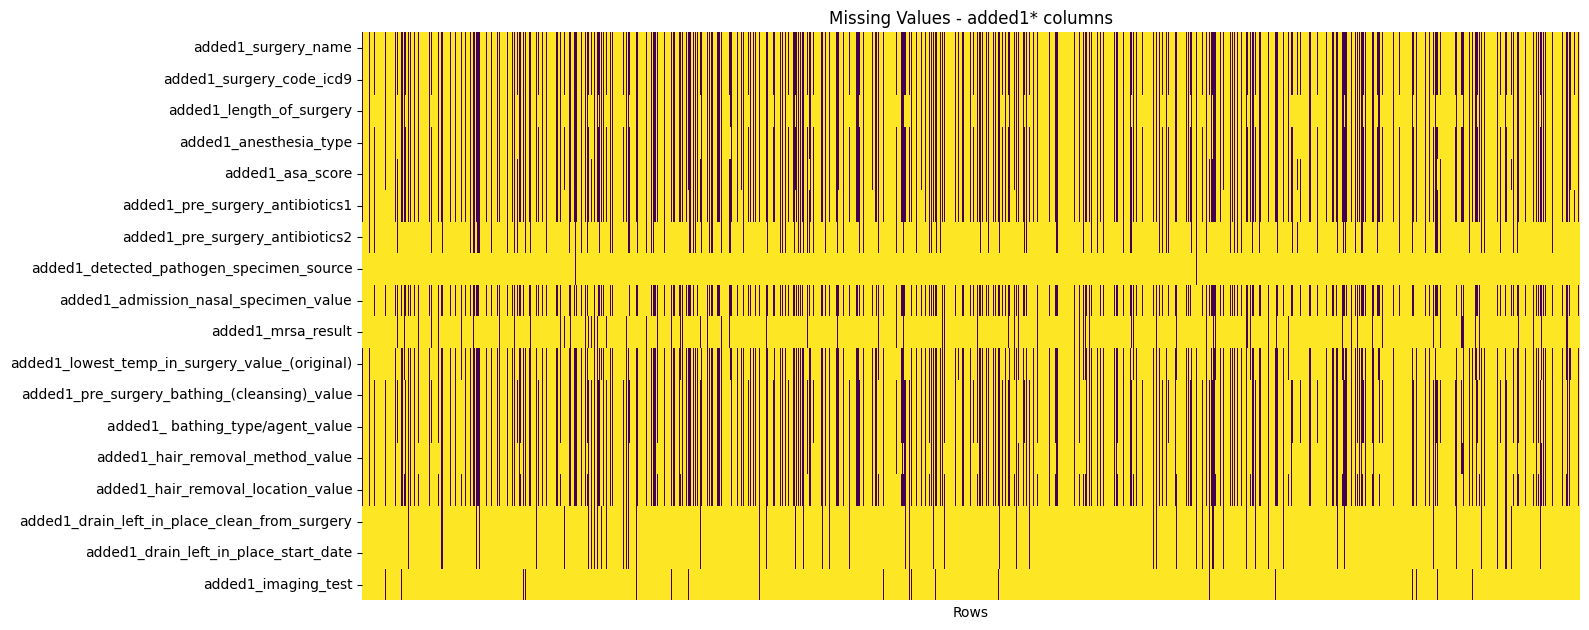

In [61]:
# ------ Missing values heatmap just on the 'added1*' columns ------
# Define the heatmap function
def plot_targeted_heatmap(data, column_list, title):
    """ Creates a missing values heatmap."""
    subset = data[column_list]
    fig, ax = plt.subplots(figsize=(16, max(3, len(column_list) * 0.3 + 1)))
    missing_matrix = subset.isnull().astype(int).T
    sns.heatmap(missing_matrix,
            cbar=False, 
            cmap = "viridis",
            vmin=0,
            vmax=1,
            xticklabels=False, 
            yticklabels=subset.columns,
            ax=ax,
            rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("Rows")
    plt.tight_layout()
    plt.show()

added_1_cols = [c for c in working.columns if c.startswith("added1")]
plot_targeted_heatmap(working, added_1_cols, "Missing Values - added1* columns")


'added1*' columns show at least two distinct missingness sub-block (not one uniform pattern):
- surgical-detail fields (surgery_name, length_of_surgery, asa_score, ect.) share one coverage pattern,
- screening fields (nasal specimen, MRSA) share a different one,
- drain/antibiotic/imaging fields are simply rare clinical events layered on top. 

Three 'added1*' fields with high missingness have candidate replacement already in the dataset with better coverage:
'added1_length_of_surgery', 'added1_surgery_name' and 'added1_asa_score'. We can remove 'added1_asa_score' because we known by the name of the column that it is the same like 'preop_asa_value'. 

In order to decide if we can remove the 2 other columns, we are doing a pair-check. because the tree columns are in different types, we will do three sorts of checking.

In [62]:
# Pair 1:  added1_length_of_surgery VS surgery_bed_dates (numeric_comparison)
_derived_len = (pd.to_datetime(working["surgey_bed_transfer_end_date"], errors="coerce")
                - pd.to_datetime(working["surgery_bed_transfer_start_date"], errors="coerce")).dt.total_seconds() / 60

_both1 = working["added1_length_of_surgery"].notna() & _derived_len.notna()
_diff = (working.loc[_both1, "added1_length_of_surgery"] - _derived_len[_both1]).abs()
print("n compared:", _both1.sum(), "| within 10 min:", (_diff <=10).mean())
display(_diff.describe())

# Pair 2: actual_activity VS added1_surgery_name (TEXT- manual eyeball sample, not exact-match)
_both2 = working["actual_activity"].notna() & working["added1_surgery_name"].notna()
print("compared columns: actual_activity VS added1_surgery_name")
display(working.loc[_both2, ["actual_activity", "added1_surgery_name"]].sample(15, random_state=42))
# we will check also the difference between icd9code of the surgery and procedure_1_icd9
_both_icd9 =working["added1_surgery_code_icd9"].notna() & working["procedure_icd9_1"].notna()
_match = working.loc[_both_icd9, "added1_surgery_code_icd9"] == working.loc[_both_icd9, "procedure_icd9_1"]
print("n compaired:", _both_icd9.sum())
print("exact match rate:", _match.mean())

_mismatch = working.loc[_both_icd9 & ~_match, ["added1_surgery_code_icd9", "procedure_icd9_1"]]
display(_mismatch.value_counts().head(15))

n compared: 6995 | within 10 min: 0.0054324517512508936


count    6995.000000
mean       68.036169
std       310.818367
min         1.000000
25%        35.000000
50%        44.000000
75%        56.000000
max      9865.000000
dtype: float64

compared columns: actual_activity VS added1_surgery_name


,actual_activity,added1_surgery_name
13666,גב-קיבוע עמוד שדרה צווארי,anterior cervical fusion using cage and plate
12115,החלפת מפרק ברך באמצעות רובוט ואליס,"tkr, total knee replacement"
15376,כירו' - סיגמואידקטומי בלאפ,laparoscopic sigmoidectomy
18437,החלפת מפרק ברך,"tkr, total knee replacement"
9632,החלפת מפרק ברך באמצעות רובוט ואליס,"tkr, total knee replacement"
16084,החלפת מפרק ברך,"tkr, total knee replacement"
1823,החלפת מפרק ברך,unicompartmental knee replacement
17898,החלפת מפרק ברך באמצעות רובוט ואליס,"tkr, total knee replacement"
22021,החלפת מפרק ירך,"thr, total hip replacement"
18697,החלפת מפרק ברך בשיטה רובוטית,"tkr, total knee replacement"


n compaired: 7966
exact match rate: 0.9354757720311323


added1_surgery_code_icd9  procedure_icd9_1
81.08                     80.51               84
80.51                     3.09                31
81.07                     3.09                27
81.02                     80.99               22
81.08                     3.09                12
36.13                     37.21               11
36.14                     37.21               10
36.1                      36.13               10
35.21                     99.99                9
45.73                     99.25                7
40.3                      6.4                  6
80.51                     80.99                6
77.89                     3.09                 6
35.12                     35.14                6
80.51                     81.07                5
Name: count, dtype: int64

### Findings:

#### 1. Zero-Variance Sheet

In the 'zero_variance_column' sheet, three columns appears, two of them are 'common_disease' columns. Those columns have only a single value across ~31,000 records. This occurs because all patients with other common diseases were excluded from our cohort (patients under 28 years-old).
Since these columns provide no informational value for modeling, we will remove them from the dataset.

One additional column, 'added1_drain_left_in_place_clean_from_surgery', also contains a single textual value ("נקז מאיזור הניתוח").  However, unlike the two other columns above, this field has 1,625 populated cells, making it clinically meaningful.
We will therefore retain this column and convert it into a binary feature:
- 'נקז מאזור הניתוח' -> '1'
- missing -> 0


#### 2. Bucket-Column: Missingness in ADDED1 columns

A large portion of the missing data appears in the "added1*" columns, originating from a dataset merge into the main medical record dataset.
Only **26%** of the cohort contains information in these fields.

We evaluated three 'added1*' columns to determine whether they can be removed, based on the existense of parallel fields in the main medical record:

##### a. Length of Surgery
There is a significant (more than 10 minutes) difference between time on the operating table and the actual surgical duration.

##### b. Surgery Name 
We first compared 'actual_activity' and 'added1_surgery_name' by sampling matched rows and confirmed the represent the same information (different wording, same procedure). We then compared the accompanying ICD9 codes = 'added1_surgery_code_icd9' vs 'procedure_icd9_1' - directly: 93% exact match.
Reviewing the 7% mismatches showed the codes were not contradictory, but described a different stage of the same multi-step operative session (e.g. a fusion code vs. a decompression code from the same spine surgery), consistent with how 'procedure_2'-'procedure_5' already represent same-session steps elsewhere in this dataset.

Given this, 'actual_activity', 'added1_surgery_name', and 'added1_surgery_code_icd9' will be dropped as redudant with the 'procedure_1'/'procedure_icd9_1' fields already retained. Before dropping, we check 'procedure_icd9_1' for missing values and, where a gap exists and one of the three columns being dropped has a value, impute the gap from that column first.

#### 3. Remaining Missing Data:
Following clinical review, dataset columns were split into two groups:
* **Clinically legitimate missingness** (e.g. sex, city, preop labs, secondary diagnosis/procedures): a missing value does not indicate an error. These are handeled now with a controlled, non-guessing approach.
* **Data-entry errors** (e.g. diaggnosis_1, procedure_1, admission cause): missing values are left as NaN and deferred to statistical imputation after thr train/test split.

For the legitimate-missingness group, each column is assigned one of three strategies via IMPUTATION_DECISIONS:
1. 'true_missing_flag_unknown' - categorical/text columns, filled with "Unknown".
2. 'not_done_flag_and_leave_nan' - numericqbinary columns where 0 is already a valid value/ The value stays NaN, and a separate '<col>_was+recorded' flag column is added insteade.
3. 'not_done_fill_value' - categorical columns where missing clearly means an event/intervention did not occur. Filled with an explicit descriptive string (e.g. "No antibiotics given).

the target column is never touched by this process.

#### 4. Removal of Physiologically Impossible Values
Based on our EDA findings, several numeric fields contain physiologically impossible values.
We will remove or correct these values at this stage to ensure data integrity before modeling.

## PHASE 1 - CHANGES (modifies `working`)

Everything here only touches columns/rows we explicitly confirmed.


In [ ]:
# 1. Zero-Variance COMMON_DISEASE columns - near-zero info after cohort restriction
ZERO_VARIANCE_COLS_TO_DROP: List[str] = ["common_disease_first_hospitalization_value_1", "common_disease_first_hospitalization_value_2"]
working, zero_variance_audit = apply_zero_variance_pruning(working, cols_to_drop = ZERO_VARIANCE_COLS_TO_DROP)
# NOTE: added_1_drain_left_in_place_clean_from_surgery stays untouched here, we will change the column to binary in stage 2.


Dropped 2 / 2 confirmed zero-variance columns.


In [ ]:
# 2a. ASA - fill preop_asa_value gaps from added1_asa_score, then drop added1
working["preop_asa_value"] = pd.to_numeric(working["preop_asa_value"], errors="coerce")
_asa_added1_numeric = pd.to_numeric(working["added1_asa_score"].astype(str).str.extract(r"(\d+)")[0], errors = "coerce")

_asa_fill_mask = working["preop_asa_value"].isna() & _asa_added1_numeric.notna()
working.loc[_asa_fill_mask, "preop_asa_value"] = _asa_added1_numeric[_asa_fill_mask]
print(f"Filled {_asa_fill_mask.sum()} preop_asa_value gap(s) from added1_asa_score.")
working = working.drop(columns=["added1_asa_score"])

Filled 1958 preop_asa_value gap(s) from added1_asa_score.


In [ ]:
# 2b. Surgery name/ICD9 - fill procedure_1/procedure_icd9_1 gaps, then drop redudant columns
_name_fill_mask = working["procedure_1"].isna() & working["actual_activity"].notna()
working.loc[_name_fill_mask, "procedure_1"] = working.loc[_name_fill_mask, "actual_activity"]
print(f"Filled {_name_fill_mask.sum()} procedure_1 gap(s) from acual_activity.")

_name_fill_mask2 = working["procedure_1"].isna() & working["added1_surgery_name"].notna()
working.loc[_name_fill_mask2, "procedure_1"] = working.loc[_name_fill_mask2, "added1_surgery_name"]
print(f"Filled {_name_fill_mask2.sum()} procedure_1 gap(s) from added1_surgery_name.")

_icd9_fill_mask = working["procedure_icd9_1"].isna() & working["added1_surgery_code_icd9"].notna()
working.loc[_icd9_fill_mask, "procedure_icd9_1"] = working.loc[_icd9_fill_mask, "added1_surgery_code_icd9"]
print(f"Filled {_icd9_fill_mask.sum()} procedure_1 gap(s) from added1_surgery_code_icd9.")

working = working.drop(columns=["actual_activity", "added1_surgery_name", "added1_surgery_code_icd9"])

Filled 1942 procedure_1 gap(s) from acual_activity.
Filled 0 procedure_1 gap(s) from added1_surgery_name.
Filled 1166 procedure_1 gap(s) from added1_surgery_code_icd9.


In [ ]:
# 3- Missing values imputation will be handled in Stage 2

In [ ]:
# 4. PHYSIOLOGICAL PLAUSIBILITY BOUNDS - IMPOSSIBLE VALUES BECOME MISSING
# ============================================================
# Outer plausibility bounds, NOT "normal" ranges. Confirm every row with your clinical
# advisor before trusting it. Deliberately NOT derived from the infected cohort or any
# target-aware statistic.
PHYSIOLOGICAL_BOUNDS: Dict[str, Tuple[float, float]] = {
    # clinical-review decisions already configured:
    "age": (0, 110),
    "preop_bmi_value": (10, 100),
    "preop_glucose_value": (20, 1000),
    "preop_sodium_value": (100, 180),
    "preop_potassium_value": (1.5, 9.0),
    "preop_creatinine_value": (0.1, 20),
    "preop_hemoglobin_value": (2, 25),
    "preop_hba1c_value": (3, 20),
    "preop_albumin_values": (1.0, 6.5),
    "added1_length_of_surgery": (1, 1440),
    "prop_urea_value": (1, 150),

    # Lowest intra-operative temperature. This is an OUTER plausibility rule,
    # not a "normal range". Values outside the approved outer range become NaN.
    "added1_lowest_temp_in_surgery_value_(original)": (35.5, 45),
}


def apply_physiological_bounds_as_missing(
    df_input: pd.DataFrame, bounds: Dict[str, Tuple[float, float]] = PHYSIOLOGICAL_BOUNDS,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    INFO:
    Values outside manually-approved outer physiological plausibility bounds are treated
    as unreliable data-entry / measurement values and converted to NaN.

    IMPORTANT:
    This is NOT statistical outlier removal. Plausible extreme values are preserved.
    No imputation is performed here; any later imputation must be learned on Train only.
    """
    result = df_input.copy()
    rows = []
    for col, (low, high) in bounds.items():
        resolved = resolve_column(result, [col], required=False)
        if resolved is None:
            rows.append({
                "column": col, "status": "column_not_found",
                "n_below_bound_set_nan": 0, "n_above_bound_set_nan": 0,
                "bound_low": low, "bound_high": high,
            })
            continue

        series = pd.to_numeric(result[resolved], errors="coerce")
        below = series.notna() & (series < low)
        above = series.notna() & (series > high)

        result.loc[below | above, resolved] = np.nan

        rows.append({
            "column": resolved,
            "status": "outside_bounds_set_to_nan",
            "n_below_bound_set_nan": int(below.sum()),
            "n_above_bound_set_nan": int(above.sum()),
            "bound_low": low,
            "bound_high": high,
        })

    audit = pd.DataFrame(rows)
    total = int(
        audit.get("n_below_bound_set_nan", pd.Series(dtype=int)).sum()
        + audit.get("n_above_bound_set_nan", pd.Series(dtype=int)).sum()
    )
    print(f"Set {total} physiologically implausible value(s) to NaN across {len(bounds)} configured column(s).")
    return result, audit

working, physiological_bounds_audit = apply_physiological_bounds_as_missing(working)
_implausible_to_nan = int(
    physiological_bounds_audit.get('n_below_bound_set_nan', pd.Series(dtype=int)).sum()
    + physiological_bounds_audit.get('n_above_bound_set_nan', pd.Series(dtype=int)).sum()
)

Set 2781 physiologically implausible value(s) to NaN across 12 configured column(s).


### Print Results Phase 1 Changes


In [ ]:
print("\n" + "=" * 60)
print("PHASE 1 SUMMARY - what actually changed")
print("=" * 60)
print(f"- Leakage columns dropped:        {(leakage_pruning_audit['status'] == 'dropped').sum()}")

print("\nTiming-gated column groups (CVC/catheter/TPN/recovery_bed/labs):")
display(timing_gate_audit)

print(f"- Zero-variance columns dropped:  {(zero_variance_audit['status'] == 'dropped').sum()}")

print(f"- Infinite values replaced:       No infinite values in this dataset")


print(f"- Physiologically implausible values -> NaN: {_implausible_to_nan}")

print(f"- Result: {len(working)} rows, {working.shape[1]} columns (started at {working.shape[1] + (leakage_pruning_audit['status']=='dropped').sum() + (zero_variance_audit['status']=='dropped').sum()})")
print("(Full per-column detail is in phase1_findings.xlsx / the final audit workbook.)")



PHASE 1 SUMMARY - what actually changed
- Leakage columns dropped:        118

Timing-gated column groups (CVC/catheter/TPN/recovery_bed/labs):


,group,gate_date_col,status,n_non_missing,n_within_window,pct_within_window,decision,n_rows_nulled,companion_cols,columns_dropped
0,CVC,CVC_start_date,audited,2236,2187,0.9781,KEPT_nulled_out_of_window_rows,29662.0,[],NaN
1,catheter,catheter_start_date,audited,4987,4294,0.8610,KEPT_nulled_out_of_window_rows,27555.0,"[catheter_route, catheter_task_name, catheter_...",NaN
2,catheter_end,catheter_end_date,audited,4986,102,0.0205,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,[catheter_end_date]
3,TPN,tpn_start_date,audited,97,5,0.0515,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,"[tpn_start_date, tpn_dose_form, tpn_drug_name,..."
4,recovery_bed,recovery_bed_transfer_end_date,audited,28837,28410,0.9852,KEPT_nulled_out_of_window_rows,3439.0,"[recovery_bed_transfer_start_date, recovery_bed]",NaN
5,lab_hemoglobin,lab_hemoglobin_first_date,audited,9181,2310,0.2516,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,"[lab_hemoglobin_first_date, lab_hemoglobin_fir..."
6,lab_crp,lab_crp_first_date,audited,3161,254,0.0804,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,"[lab_crp_first_date, lab_crp_first_value_mg/L]"
7,lab_creatinine,lab_creatinine_first_date,audited,9502,2170,0.2284,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,"[lab_creatinine_first_date, lab_creatinine_fir..."
8,lab_glucose,lab_glucose_first_date,audited,9011,2120,0.2353,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,"[lab_glucose_first_date, lab_glucose_first_val..."
9,lab_plt,lab_plt_first_date,audited,9181,2310,0.2516,DROPPED_ENTIRE_GROUP (below 70%),NaN,NaN,"[lab_plt_first_date, lab_plt_first_value_10^3/µL]"


- Zero-variance columns dropped:  2
- Infinite values replaced:       No infinite values in this dataset
- Physiologically implausible values -> NaN: 2781
- Result: 31849 rows, 93 columns (started at 213)
(Full per-column detail is in phase1_findings.xlsx / the final audit workbook.)



# Phase 2 - Local (Column-by-Column) Processing

In this phase we are focusing on column-level cleaning - implausible dates, duplicated/inconsistent category wording, clinically approved missing-value decisions, and specific cleanup rules agreed for individual variables.

**What is not done here:**  
- Frequency-based rare-category grouping is **not** performed in Cleaning; it is fitted on Train only in Step 6.  
- Distribution-dependent imputation (median/mode/KNN) is performed only after the split and fitted on Train.

### Structure: Findings first, then Changes
Same pattern as Phase 1 - review the Findings before running the Changes cell.


### PHASE 2 - read-only, changes nothing


In [68]:
def summarize_numeric_columns(df_input: pd.DataFrame, columns: Optional[List[str]] = None) -> pd.DataFrame:
    """INFO: Read-only. One row per numeric column: n, missing%, n_unique only (kept minimal on purpose)."""
    if columns is None:
        columns = df_input.select_dtypes(include=[np.number]).columns.tolist()
    rows = []
    for col in columns:
        s = df_input[col]
        rows.append({
            "column": col,
            "n_non_missing": int(s.notna().sum()),
            "pct_missing": round(100 * s.isna().mean(), 2),
            "n_unique": int(s.nunique(dropna=True)),
        })
    return pd.DataFrame(rows).sort_values("pct_missing", ascending=False)


def discover_datetime_pairs(df_input: pd.DataFrame) -> List[Tuple[str, str, str]]:
    """INFO: Discover conservative start/end naming pairs for chronology auditing. No values are changed."""
    columns = list(df_input.columns)
    key_to_col = {_canonical_key(c): c for c in columns}
    pairs = []
    substitutions = [
        (" start date", " end date"), (" insertion date", " removal date"),
        (" entry date", " exit date"), (" admission date", " discharge date"),
        (" begin date", " end date"),
    ]
    for col in columns:
        key = _canonical_key(col)
        for start_token, end_token in substitutions:
            if key.endswith(start_token):
                counterpart_key = key[: -len(start_token)] + end_token
                end_col = key_to_col.get(counterpart_key)
                if end_col is not None:
                    pairs.append((f"{col} <= {end_col}", col, end_col))
    return list(dict.fromkeys(pairs))


def chronology_audit(df_input: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """INFO: Audit central hospitalization chronology and discovered start/end pairs. Nothing is changed."""
    summary_rows, invalid_rows = [], []
    surgery_col = resolve_column(df_input, SURGERY_DATE_CANDIDATES, required=False)
    admission_col = resolve_column(df_input, ADMISSION_DATE_CANDIDATES, required=False)
    discharge_col = resolve_column(df_input, DISCHARGE_DATE_CANDIDATES, required=False)

    checks = []
    if admission_col and surgery_col:
        checks.append(("admission_before_or_at_surgery", admission_col, surgery_col))
    if surgery_col and discharge_col:
        checks.append(("surgery_before_or_at_discharge", surgery_col, discharge_col))
    if admission_col and discharge_col:
        checks.append(("admission_before_or_at_discharge", admission_col, discharge_col))
    checks.extend(discover_datetime_pairs(df_input))

    seen = set()
    for check_name, start_col, end_col in checks:
        key = (start_col, end_col)
        if key in seen:
            continue
        seen.add(key)
        start = pd.to_datetime(df_input[start_col], errors="coerce")
        end = pd.to_datetime(df_input[end_col], errors="coerce")
        invalid = start.notna() & end.notna() & end.lt(start)
        summary_rows.append({
            "check": check_name, "start_column": start_col, "end_column": end_col,
            "comparable_rows": int((start.notna() & end.notna()).sum()),
            "invalid_order_count": int(invalid.sum()),
        })
        if invalid.any():
            detail_cols = [c for c in [case_id_col, start_col, end_col] if c in df_input.columns]
            tmp = df_input.loc[invalid, detail_cols].copy()
            tmp["check"] = check_name
            invalid_rows.append(tmp)

    summary = pd.DataFrame(summary_rows)
    details = pd.concat(invalid_rows, ignore_index=True) if invalid_rows else pd.DataFrame()
    return summary, details


def audit_date_plausibility(
    df_input: pd.DataFrame, columns: Optional[List[str]] = None,
    earliest_valid: str = "2022-01-01", latest_valid: Optional[str] = None,
) -> pd.DataFrame:
    """
    INFO:
    Read-only. For each datetime column: how many values fall before `earliest_valid` or
    after `latest_valid` (defaults to today). earliest_valid is set to 2022-01-01 (not
    2023) because the clinical advisor may have deliberately included 2022 records —
    this is a code-only decision for now, not confirmed with the advisor yet.
    """
    if latest_valid is None:
        latest_valid = pd.Timestamp.today().normalize()
    earliest_valid = pd.Timestamp(earliest_valid)
    latest_valid = pd.Timestamp(latest_valid)
    if columns is None:
        columns = [c for c in df_input.columns if pd.api.types.is_datetime64_any_dtype(df_input[c])]
    rows = []
    for col in columns:
        s = df_input[col]
        before = s.notna() & (s < earliest_valid)
        after = s.notna() & (s > latest_valid)
        rows.append({"column": col, "n_before_earliest": int(before.sum()), "n_after_latest_future": int(after.sum()),
                     "earliest_seen": s.min(), "latest_seen": s.max()})
    return pd.DataFrame(rows)


def find_boolean_conversion_candidates(df_input: pd.DataFrame, max_categories: int = 3) -> pd.DataFrame:
    """
    INFO:
    Read-only. Text-like columns with <= max_categories distinct non-missing values.
    'category_type' distinguishes: already_binary_numeric (already [0,1] — nothing to
    do), single_value_presence_only (only 1 distinct value ever appears — this is a
    presence/absence signal, not a semantic Yes/No; see zero-variance findings too),
    and genuine_small_categorical (2-3 real distinct text categories — may or may not
    be a true Yes/No, needs your eyes).
    """
    text_cols = [c for c in df_input.columns if _is_text_like(df_input[c]) or pd.api.types.is_numeric_dtype(df_input[c])]
    rows = []
    for col in text_cols:
        uniques = df_input[col].dropna().unique().tolist()
        if not (0 < len(uniques) <= max_categories):
            continue
        if set(uniques) <= {0, 1, 0.0, 1.0}:
            category_type = "already_binary_numeric"
        elif len(uniques) == 1:
            category_type = "single_value_presence_only"
        else:
            category_type = "genuine_small_categorical"
        rows.append({"column": col, "n_categories": len(uniques), "category_type": category_type, "values": uniques})
    return pd.DataFrame(rows).sort_values(["category_type", "n_categories"]) if rows else pd.DataFrame()


def _strip_common_affix_for_comparison(values: List[str]) -> List[str]:
    """INFO: Internal helper — strips a shared literal prefix across ALL values, for comparison only (does not touch real data)."""
    if len(values) < 2:
        return values
    import os
    common = os.path.commonprefix(values)
    # Only strip if the common prefix is a meaningful chunk (not just 1-2 chars) and
    # what's left still has content (avoid stripping the whole string to nothing).
    if len(common) >= 4 and all(len(v) > len(common) for v in values):
        return [v[len(common):] for v in values]
    return values


def find_near_duplicate_categories(
    df_input: pd.DataFrame, max_categories_to_scan: int = 30, similarity_threshold: float = 0.6,
) -> pd.DataFrame:
    """
    INFO:
    Read-only. Compares every pair of values (per column) with SequenceMatcher and flags
    pairs above similarity_threshold as CANDIDATES for manual review. Before comparing,
    strips any prefix shared by ALL of a column's values (e.g. "room 12" vs "room 34"
    share "room " — that's not a real near-duplicate, just two different room numbers
    with the same label) so shared-boilerplate text doesn't create false-positive matches.
    """
    text_cols = [c for c in df_input.columns if _is_text_like(df_input[c])]
    rows = []
    for col in text_cols:
        uniques = df_input[col].dropna().unique().tolist()
        if not (3 < len(uniques) <= max_categories_to_scan):
            continue
        str_uniques = [str(u) for u in uniques]
        compare_values = _strip_common_affix_for_comparison(str_uniques)
        for i in range(len(uniques)):
            for j in range(i + 1, len(uniques)):
                score = SequenceMatcher(None, compare_values[i], compare_values[j]).ratio()
                if score >= similarity_threshold:
                    rows.append({"column": col, "value_a": str_uniques[i], "value_b": str_uniques[j], "similarity": round(score, 3)})
    return pd.DataFrame(rows).sort_values("similarity", ascending=False) if rows else pd.DataFrame()


def summarize_binary_like_columns(df_input: pd.DataFrame, columns: Optional[List[str]] = None) -> pd.DataFrame:
    """
    INFO:
    Read-only. Loops over Boolean-like columns and shows n_zero/n_one/n_missing side by
    side. Excludes fully-missing columns on purpose — an all-NaN column vacuously looked
    "binary" before (empty set is a subset of anything), which was misleading.
    """
    if columns is None:
        columns = [
            c for c in df_input.columns
            if df_input[c].notna().any()
            and set(df_input[c].dropna().unique().tolist()) <= {0, 1, 0.0, 1.0}
        ]
    rows = []
    for col in columns:
        s = df_input[col]
        rows.append({"column": col, "n_zero": int((s == 0).sum()), "n_one": int((s == 1).sum()),
                     "n_missing": int(s.isna().sum()), "pct_missing": round(100 * s.isna().mean(), 2)})
    return pd.DataFrame(rows).sort_values("pct_missing", ascending=False) if rows else pd.DataFrame()




### Run Phase 2 Findings


In [69]:
show("Numeric columns - n / missing% / unique values:")
numeric_summary = summarize_numeric_columns(working)
display(numeric_summary)

show("Chronology check - start/end date pairs where the order is impossible "
     "(end before start):")
chrono_summary, chrono_details = chronology_audit(working)
display(chrono_summary)
print("INSIGHT: 'invalid_order_count' > 0 means some rows have an end date earlier than "
      "their start date for that pair - worth a manual look at chrono_details before "
      "trusting those columns.")

show("Datetime plausibility - values before 2022-01-01 or in the future "
     "(earliest_valid is a code-only choice for now, not yet confirmed with the "
     "clinical advisor):")
date_plausibility = audit_date_plausibility(working)
flagged_dates = date_plausibility[(date_plausibility["n_before_earliest"] > 0) | (date_plausibility["n_after_latest_future"] > 0)]
display(flagged_dates.sort_values("n_after_latest_future", ascending=False))
print(f"INSIGHT: {len(flagged_dates)} / {len(date_plausibility)} datetime column(s) have "
      "implausible values. A LARGE n_before_earliest (hundreds+) on one column while "
      "others show single digits usually means a genuine parsing/default-value problem "
      "in that specific column (e.g. an Excel epoch default of 1900), not a real-world "
      "date issue — worth checking that column specifically.")

show("Boolean-conversion candidates - text/numeric columns with <=3 distinct values, "
     "split by what they actually are:")
boolean_candidates = find_boolean_conversion_candidates(working)
display(boolean_candidates)
print("INSIGHT: 'already_binary_numeric' needs no action. 'single_value_presence_only' "
      "means the column only ever records ONE outcome when present - that's a presence/"
      "absence signal, not a real Yes/No; it usually overlaps with the zero-variance "
      "findings from Phase 1. 'genuine_small_categorical' needs your eyes - it may or "
      "may not be a real binary flag.")

show("Near-duplicate category text (candidates only - shared boilerplate prefixes are "
     "already stripped from the comparison so they don't create false positives):")
near_duplicates = find_near_duplicate_categories(working)
display(near_duplicates.head(30))

show("Binary-like columns - n_zero / n_one / n_missing (fully-missing columns excluded):")
binary_summary = summarize_binary_like_columns(working)
display(binary_summary)


show("Cross-column clinical consistency - rows that fail rules confirmed with the clinical advisor:")
CONSISTENCY_RULES: List[Dict[str, Any]] = [
    {"name": "diabetes_no_but_high_hba1c", "columns": ["preop_diabetes", "preop_hba1c_value"],
     "check": lambda df: (df["preop_diabetes"] == 0) & (df["preop_hba1c_value"] > 6.5)},
]
consistency_rows = []
for rule in CONSISTENCY_RULES:
    missing_cols = [c for c in rule["columns"] if c not in working.columns]
    if missing_cols:
        consistency_rows.append({"rule": rule["name"], "status": "columns_not_found", "n_violations": 0})
        continue
    mask = rule["check"](working)
    consistency_rows.append({"rule": rule["name"], "status": "checked", "n_violations": int(mask.sum())})
consistency_audit = pd.DataFrame(consistency_rows)
display(consistency_audit)



>>> Numeric columns - n / missing% / unique values:


,column,n_non_missing,pct_missing,n_unique
10,preop_albumin_values,95,99.70,16
9,preop_hba1c_value,2659,91.65,121
14,added1_lowest_temp_in_surgery_value_(original),5339,83.24,25
12,elderly_assessment_scanner_score_value,6685,79.01,18
13,added1_length_of_surgery,6981,78.08,328
8,prop_urea_value,10221,67.91,524
5,preop_glucose_value,15703,50.70,494
7,preop_sodium_value,19479,38.84,139
6,preop_potassium_value,19550,38.62,245
4,preop_creatinine_value,23017,27.73,280



>>> Chronology check - start/end date pairs where the order is impossible (end before start):


,check,start_column,end_column,comparable_rows,invalid_order_count
0,admission_before_or_at_surgery,admission_date,activity_date,31794,46
1,recovery_bed_transfer_start_date <= recovery_b...,recovery_bed_transfer_start_date,recovery_bed_transfer_end_date,28402,0


INSIGHT: 'invalid_order_count' > 0 means some rows have an end date earlier than their start date for that pair - worth a manual look at chrono_details before trusting those columns.

>>> Datetime plausibility - values before 2022-01-01 or in the future (earliest_valid is a code-only choice for now, not yet confirmed with the clinical advisor):


...

,column,value_a,value_b,similarity
63,surgery_bed,חדר ניתוח - רמת החיל- 3,חדר ניתוח - רמת החיל- 13,0.979
89,surgery_bed,חדר ניתוח - רמת החיל- 12,חדר ניתוח - רמת החיל- 1,0.979
166,surgery_bed,חדר ניתוח - רמת החיל- 15,חדר ניתוח - רמת החיל- 1,0.979
179,surgery_bed,חדר ניתוח - רמת החיל- 17,חדר ניתוח - רמת החיל- 1,0.979
182,surgery_bed,חדר ניתוח - רמת החיל- 17,חדר ניתוח - רמת החיל- 7,0.979
188,surgery_bed,חדר ניתוח - רמת החיל- 1,חדר ניתוח - רמת החיל- 14,0.979
189,surgery_bed,חדר ניתוח - רמת החיל- 1,חדר ניתוח - רמת החיל- 13,0.979
186,surgery_bed,חדר ניתוח - רמת החיל- 1,חדר ניתוח - רמת החיל- 11,0.979
185,surgery_bed,חדר ניתוח - רמת החיל- 1,חדר ניתוח - רמת החיל- 16,0.979
150,surgery_bed,חדר ניתוח - רמת החיל- 6,חדר ניתוח - רמת החיל- 16,0.979



>>> Binary-like columns - n_zero / n_one / n_missing (fully-missing columns excluded):


,column,n_zero,n_one,n_missing,pct_missing
0,target_binary,31708,141,0,0.0



>>> Cross-column clinical consistency - rows that fail rules confirmed with the clinical advisor:


,rule,status,n_violations
0,diabetes_no_but_high_hba1c,checked,0


### Save Phase 2 Findings to Excel - open and review BEFORE deciding what to change

Same idea as Phase 1: this saves before the Phase 2 Changes cell below runs anything. Open it, decide what belongs in `CATEGORY_NORMALIZATION_MAP` / the simple `MISSING_MEANS_*` groups / `UNIT_CONVERSION_FACTORS` / `DRUG_GROUP_TARGET_UNIT`, edit those cells above, then run Changes.


In [70]:
PHASE2_FINDINGS_PATH = OUTPUT_DIR / "00_findings_before_changes" / "phase2_findings.xlsx"
PHASE2_FINDINGS_PATH.parent.mkdir(parents=True, exist_ok=True)
phase2_findings_tables = {
    "numeric_summary": numeric_summary,
    "chronology_summary": chrono_summary,
    "chronology_details": chrono_details,
    "date_plausibility": date_plausibility,
    "boolean_candidates": boolean_candidates,
    "near_duplicate_categories": near_duplicates,
    "binary_column_summary": binary_summary,
    "cross_column_consistency": consistency_audit,
}
if SAVE_OUTPUTS:
    _non_empty = {n: t for n, t in phase2_findings_tables.items() if isinstance(t, pd.DataFrame) and not t.empty}
    if not _non_empty:
        print("Phase 2 findings: nothing to save (all tables empty — good news, no issues found).")
    else:
        try:
            with pd.ExcelWriter(PHASE2_FINDINGS_PATH, engine="openpyxl") as writer:
                for name, table in _non_empty.items():
                    table.to_excel(writer, sheet_name=name[:31], index=False)
            print(f"Phase 2 findings saved to: {PHASE2_FINDINGS_PATH}")
        except Exception as exc:
            print(f"WARNING: Could not save Phase 2 findings workbook: {exc}")


Phase 2 findings saved to: H:\27 project\cleaning\cleaning_outputs\00_findings_before_changes\phase2_findings.xlsx


## Stage 2 Findings


**1. Chronological inconsistencies**

A small number of records contained an 'activity_date' earlier than the corresponding 'admission_date'.
- Short discrepancies of up to 24 hours are treated as likely clock, documentation, or cross-midnight artifacts. In this cases, only the component is removed while preserving the recorded calendar date.
- Larger discrepancies of more than 24 hours are treated as genuine data-quality problems. In these cases, both timestamps are set to missing rather than attempting to infer or correct the original values.

**2. Boolean columns containing non-binary values**

Several variables that are intended to represent Boolean information were found to contain values other than strict `0/1` encoding, including textual labels and inconsistent representations. These inconsistencies require standardization before the variables can be used reliably in downstream analysis and modeling.

**3. Similarity-sheet inconsistencies and near-duplicate categories**

Review of the similarity sheet showed that a high textual similarity score does not necessarily indicate that two values should be merged. Some pairs represented true formatting or naming redundancies, while others were clinically or operationally distinct despite having similar text. Therefore, similarity scores were used as a review aid rather than as an automatic merging rule.

#### Findings by variable

- **`surgery_bed`**  
  Values shared a repeated non-informative prefix, while the final number represented the actual bed/room identifier. The prefix therefore adds no useful discriminatory information, whereas the numeric identifier should be preserved.

- **`catheter_task_name`**  
  Values such as `ch 8`, `ch 12`, `ch 20`, etc. were frequently flagged as similar because of the shared `ch` prefix. These are distinct task/channel values and should remain separate.

- **`admission_year`, `admission_weekday`, and `preop_asa_value`**  
  Similarity between these values reflects textual or numeric resemblance only. Different years, weekdays, and ASA values represent distinct categories and should not be merged.

- **`surgeon_specialization`**  
  Several values were similar because of shared terms, punctuation differences, ordering, spacing, or spelling variation. Only formatting normalization should be performed. Different surgical specialties should remain separate unless two values clearly describe the same set of specialties using different wording.

- **`department`**  
  Several department values included the repeated suffix `-רמת החייל`. Since this suffix does not distinguish between departments within the dataset, it can be removed while preserving the informative part appearing before it.

- **`icu_bed`**  
  Similar to `surgery_bed`, the repeated prefix `טיפול נמרץ- רמח-` does not provide additional discriminatory information, while the final number represents the ICU bed/unit identifier.

- **`added1_admission_nasal_specimen_value`**  
  Two values were identified as equivalent for the purpose of this project:
  `בוצע משטח רגיל וטרם התקבלה תשובה` and  
  `בוצע משטח PCR וטרם התקבלה תשובה`.  
  In both cases, the clinically relevant information at the prediction point is that a nasal specimen was collected but the result was not yet available.
  We also united a couple sets of two calegories ('positive' and 'חיובי', and 'negative' and 'שלילי')..

- **`added1_detected_pathogen_specimen_source`**  
  Values describing `סיקור קבלה` and `סיקור אשפוז` should remain separate, since they represent different clinical timing/context: screening at admission versus screening performed during hospitalization.

- **`added1_imaging_test`**  
  Similarity often reflected shared modality terms such as CT or MRI, while the anatomical site or specific examination differed. Different imaging examinations should therefore remain distinct, with only spelling, spacing, capitalization, and punctuation normalized.

- **Preoperative antibiotic variables**  
  Different antibiotic names should remain distinct even when textual similarity is high. Only formatting and clearly equivalent naming conventions should be standardized.

- **`added1_asa_score`**  
  This variable is excluded from the downstream modeling pipeline and therefore does not require similarity-based normalization.


## PHASE 2 - CHANGES 

### Changes Made


* Chronologically impossible `admission_date` / `activity_date` pairs are handled according to the size of the discrepancy:

  * gaps of **≤24 hours** are treated as likely timing/rounding artifacts and normalized to calendar-date level;
  * gaps of **>24 hours** are treated as data-quality errors and both values are set to missing rather than guessed.

* Boolean variables with inconsistent representations are standardized to strict binary `0/1` encoding.

* In the similarity sheet, non-informative shared prefixes are removed where appropriate, and near-duplicate values are consolidated into a single canonical category only when their underlying meaning is confirmed to be equivalent.

  - `surgery_bed` is transformed by removing the repeated textual prefix and retaining the bed/room number only. The column is renamed to **`surgery_bed_number`**.

  - `catheter_task_name`, `admission_year`, `admission_weekday`, and `preop_asa_value` retain their original distinct values.

  - `surgeon_specialization` undergoes formatting normalization only. Different specialties are not merged solely because of textual similarity.

  - For `department`, the suffix `-רמת החייל` is removed when present, while the department name itself is retained.

  - `icu_bed` is transformed by removing the repeated prefix `טיפול נמרץ- רמח-` and retaining the numeric identifier. The column is renamed to **`icu_bed_number`**.

  - In `added1_admission_nasal_specimen_value`, the two pending-result values:
    - `בוצע משטח רגיל וטרם התקבלה תשובה`
    - `בוצע משטח PCR וטרם התקבלה תשובה`
    
    are consolidated into a single canonical category representing **specimen collected, result pending**.

  - `added1_detected_pathogen_specimen_source` preserves the distinction between admission screening (`סיקור קבלה`) and inpatient screening (`סיקור אשפוז`).

  - `added1_imaging_test` is normalized for formatting only; different examinations remain separate.

  - Preoperative antibiotics: Different antibiotic agents were preserved as distinct values, with formatting normalization only.

  - `mental_health`: Common Hebrew and English variations of anxiety, depression, and PTSD were standartized into consistent categories, while all other values were left unchanged.

  Overall, similarity-based cleaning is therefore restricted to **confirmed formatting redundancies and semantically equivalent values**, while clinically or operationally distinct categories remain separate.

In [ ]:
# CHRONOLOGICAL CONSISTENCY: activity_date must not precede admission_date

if ("admission_date" in working.columns and "activity_date" in working.columns):

    working["admission_date"] = pd.to_datetime(working["admission_date"], errors="coerce",)
    working["activity_date"] = pd.to_datetime(working["activity_date"], errors="coerce",)

    _gap_hours = (working["admission_date"] - working["activity_date"]).dt.total_seconds() / 3600
    _bad_order = (working["activity_date"] < working["admission_date"])

    # Small discrepancies are considered likely clock, rounding or cross-midnight artifacts.
    _small_gap = (_bad_order & (_gap_hours <= 24))
    # Larger discrepancies are treated as genuine data-quality problems.
    _large_gap = (_bad_order & (_gap_hours > 24))

    working.loc[_small_gap,"admission_date",] = (working.loc[_small_gap,"admission_date",].dt.normalize())
    working.loc[_small_gap, "activity_date",] = (working.loc[_small_gap,"activity_date",].dt.normalize())
    working.loc[_large_gap, ["admission_date", "activity_date"]] = pd.NaT

    print(f"Chronology fix: {_small_gap.sum()} row(s) date-truncated, {_large_gap.sum()} row(s) set to missing.")

Chronology fix: 28 row(s) date-truncated, 18 row(s) set to missing.


In [ ]:
# BINARY VARIABLE STANDARDIZATION
# Binary variables are renamed so that the meaning of value=1 is explicit from the column name itself.
# Unexpected values are NOT silently forced into 0/1. They become NaN and are reported in the audit.
def map_binary_column(df_input: pd.DataFrame, source_col: str, new_col: str, mapping: dict,) -> pd.DataFrame:
    """
    Map an existing two-level variable to explicit 0/1 coding and
    rename it so that the meaning of 1 is clear.
    """

    if source_col not in df_input.columns:
        print(f"INFO: {source_col} not found - skipped.")
        return df_input

    original = df_input[source_col].copy()

    # Normalize strings while preserving numeric values.
    normalized = original.map(lambda x: str(x).strip() if pd.notna(x) else x)
    mapped = normalized.map(mapping)
    unexpected_mask = (original.notna() & mapped.isna())

    if unexpected_mask.any():
        print(f"WARNING: {source_col} contains "
            f"{int(unexpected_mask.sum())} unexpected non-missing value(s):")
        print(original.loc[unexpected_mask].value_counts(dropna=False).head(20))

    df_input[new_col] = mapped.astype("Int64")

    if new_col != source_col:
        df_input = df_input.drop(columns=[source_col])

    print(f"{source_col} -> {new_col} | "
        f"0={int((df_input[new_col] == 0).sum())}, "
        f"1={int((df_input[new_col] == 1).sum())}, "
        f"missing={int(df_input[new_col].isna().sum())}"
    )

    return df_input


# Sex: 1 = male, 0 = female
working = map_binary_column(working,source_col="sex",new_col="is_male",mapping={"זכר": 1, "נקבה": 0,},)

# Tourist status: 1 = passport / tourist, 0 = Israeli ID
working = map_binary_column(working, source_col="tourist", new_col="is_tourist", mapping={"דרכון": 1, "ת.ז": 0, "ת.ז.": 0,},)

working = map_binary_column(working, source_col="added1_drain_left_in_place_clean_from_surgery", new_col="added1_drain_left_in_place_clean_from_surgery", mapping={"נקז מאיזור ניתוח": 1, "": 0,},)
working["added1_drain_left_in_place_clean_from_surgery"] = working["added1_drain_left_in_place_clean_from_surgery"].fillna(0).astype(int)
# Update binary indicator to 1 if "catheter_order_dose_remarks" indicate placement from operating room
from_surgery_mask = working["catheter_order_dose_remarks"].astype(str).str.contains("מחדר ניתוח", na=False)
working.loc[from_surgery_mask, "added1_drain_left_in_place_clean_from_surgery"] = 1


sex -> is_male | 0=14941, 1=16856, missing=52
tourist -> is_tourist | 0=16238, 1=296, missing=15315
added1_drain_left_in_place_clean_from_surgery -> added1_drain_left_in_place_clean_from_surgery | 0=0, 1=1625, missing=30224


In [ ]:
# Similarity-sheet approved cleaning changes

# Helper: basic text normalization only
def normalize_text_value(value):
    """
    Basic formatting normalization only:
    - strip leading/trailing spaces
    - collapse repeated spaces
    - normalize spaces around hyphens

    Does NOT merge clinically different categories.
    """
    if pd.isna(value):
        return value

    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    value = re.sub(r"\s*-\s*", "-", value)

    return value


# 1. surgery_bed- Keep only the bed/room number and rename the column
if "surgery_bed" in working.columns:
    # Example: "חדר ניתוח - רמת החייל - 17"  ->  17
    surgery_bed_number = (working["surgery_bed"].astype("string").str.extract(r"(\d+)\s*$", expand=False))
    working["surgery_bed_number"] = pd.to_numeric(surgery_bed_number,errors="coerce")
    working = working.drop(columns=["surgery_bed"])


# 2. catheter_task_name: Do NOT merge values such as ch 8, ch 12, ch 20, etc. Only normalize formatting.
if "catheter_task_name" in working.columns:
    working["catheter_task_name"] = (working["catheter_task_name"].apply(normalize_text_value))

# 3. surgeon_specialization: Formatting normalization only.Different specialties remain separate.
if "surgeon_specialization" in working.columns:
    working["surgeon_specialization"] = (working["surgeon_specialization"].apply(normalize_text_value))


# 4A. department: Remove only the repeated suffix "-רמת החייל"
if "department" in working.columns:
    working["department"] = (working["department"].astype("string").str.strip().str
                        .replace(r"\s*-\s*רמת\s*החייל\s*$","",regex=True).str.strip())


# 4B. icu_bed: Remove the repeated ICU prefix, keep only the number, and rename to icu_bed_number
if "icu_bed" in working.columns:
    # Example: "טיפול נמרץ-רמח-13" -> 13
    icu_bed_number = (working["icu_bed"].astype("string").str.
                      replace(r"^\s*טיפול\s*נמרץ\s*-\s*רמח\s*-\s*", "", regex=True)
                      .str.extract(r"(\d+)\s*$", expand=False)
    )

    working["icu_bed_number"] = pd.to_numeric(icu_bed_number, errors="coerce")
    working = working.drop(columns=["icu_bed"])


# 5. added1_admission_nasal_specimen_value: Merge ONLY the two approved "result pending" categories:
# "בוצע משטח רגיל וטרם התקבלה תשובה"
# "בוצע משטח PCR וטרם התקבלה תשובה"
# The distinction between regular/PCR is intentionally removed only for these two pending-result states.
if "added1_admission_nasal_specimen_value" in working.columns:
    col = "added1_admission_nasal_specimen_value"
    working[col] = working[col].apply(normalize_text_value)

    nasal_pending_map = {
        "בוצע משטח רגיל וטרם התקבלה תשובה": "בוצע משטח וטרם התקבלה תשובה",
        "בוצע משטח PCR וטרם התקבלה תשובה": "בוצע משטח וטרם התקבלה תשובה",
        "שלילי":"negative",
        "חיובי":"positive"
    }

    working[col] = working[col].replace(nasal_pending_map)


# 6. added1_detected_pathogen_specimen_source
# DO NOT merge:"סיקור קבלה" & "סיקור אשפוז"
# They represent different clinical contexts. Formatting normalization only.
if "added1_detected_pathogen_specimen_source" in working.columns:
    working["added1_detected_pathogen_specimen_source"] = (
        working["added1_detected_pathogen_specimen_source"].apply(normalize_text_value)
    )

# 7. added1_imaging_test
# Do NOT merge different examinations based on similarity (CT/MRI of different anatomical sites).
# Formatting normalization only.
if "added1_imaging_test" in working.columns:
    working["added1_imaging_test"] = (working["added1_imaging_test"].apply(normalize_text_value))


# 8. Preoperative antibiotic columns
# Do NOT merge different antibiotics based on textual similarity.
# Formatting normalization only.
ANTIBIOTIC_COLS = ["added1_pre_surgery_antibiotics1","added1_pre_surgery_antibiotics2",]
for col in ANTIBIOTIC_COLS:
    if col in working.columns:
        working[col] = working[col].apply(normalize_text_value)

# 9.mental_health column- a lot of variations to common mental health issues
col = working["preop_mental_health"].astype(str)
#define matching conditions for hebrew and english variations
conditions = [
    col.str.contains(r'חרד|לחץ נפשי|anx|panic|pamic', case=False, na=False),
    col.str.contains(r'דיכא|דכא|\b(dep|depress\w*)\b', case=False, na=False),
    col.str.contains(r'ptsd|trauma|טראומה')
]
#standartized target categories
choices = ['anxiety', 'depression', 'ptsd']
# map matche categories while preserving all other unique values untouched
working['preop_mental_health'] = np.select(conditions, choices, default=working["preop_mental_health"])

# 10. conbining the 2 catrgories in "added1_anesthesia_type" and in "added1_mrsa_result"
if "added1_anesthesia_type" in working.columns:
    col = "added1_anesthesia_type"
    working[col] = working[col].apply(normalize_text_value)

    anesthesia_pending_map = {"mac": "sedation"}
    working[col] = working[col].replace(anesthesia_pending_map)

# "added1_mrsa_result" has "חיובי" and positive, also in the negative categories
if "added1_mrsa_result" in working.columns:
    col = "added1_mrsa_result"
    working[col] = working[col].apply(normalize_text_value)

    mrsa_pending_map = {

        "שלילי":"negative",
        "חיובי":"positive"
    }

    working[col] = working[col].replace(mrsa_pending_map)

# 11. organizing (combining and removing) categories from "added1_ bathing_type/agent_value" and "added1_hair_removal_location_value"
merge_map = {
    "added1_ bathing_type/agent_value": {"לא רלוונטי": "לא בוצעה רחצה"},
    "added1_hair_removal_location_value": {"לא רלוונטי": "אין צורך"}
}

drop_values = {
    "added1_ bathing_type/agent_value": ["ערב+ בוקר", "ערב הניתוח", "בוקר הניתוח", "1", "צום"],
    "added1_hair_removal_location_value": ["רחצה בבוקר עם מגבוני המחלקה", "קליפר", "0", "סכין גילוח", "טרם בוצע"]   
} 

for col, m in merge_map.items():
    working[col] = working[col].replace(m)

for col, vals in drop_values.items():
    working[col] = working[col].replace(vals, np.nan)


# ============================================================
# Quick audit
# ============================================================

print("Similarity-sheet cleaning completed.")

for col in [
    "surgery_bed_number",
    "icu_bed_number",
    "department",
    "surgeon_specialization",
    "added1_admission_nasal_specimen_value",
    "added1_detected_pathogen_specimen_source",
    "added1_imaging_test",
    "catheter_task_name",
]:
    if col in working.columns:
        print(f"\n{col}:")
        print(working[col].value_counts(dropna=False).head(20))

Similarity-sheet cleaning completed.

surgery_bed_number:
surgery_bed_number
10      3111
12      2846
16      2499
9       2451
4       2438
3       2094
2       2012
1       1981
5       1832
6       1756
8       1736
15      1686
11      1541
17      1331
7       1271
18      1056
<NA>     206
14         1
13         1
Name: count, dtype: Int64

icu_bed_number:
icu_bed_number
<NA>    29191
6         463
7         403
8         397
10        391
11        280
4         191
9         151
12        112
3          88
5          75
13         56
2          41
1          10
Name: count, dtype: Int64

department:
department
חדר ניתוח                         31562
צינתורים                            230
הדמייה פולשנית                       38
מח' אורטופדיה א'/נוירוכירורגיה        8
מח' לב/חזה                            4
יחידת מוז-רמת החיל                    3
מח' כירורגיה א'                       2
פנימית/המטולוגיה/אונקולוגיה           2
Name: count, dtype: Int64

surgeon_specialization:
s

C:\Users\mtal\AppData\Local\Temp\3\ipykernel_15088\3893092759.py:104: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  col.str.contains(r'דיכא|דכא|\b(dep|depress\w*)\b', case=False, na=False),


In [75]:
# ============================================================
# Approved category (semantic) normalization - DEFERRED, one column confirmed
# ============================================================
CATEGORY_NORMALIZATION_MAP: Dict[str, Dict[str, str]] = {
    "preop_regular_medications": {
        "ללא טיפול תרופתי קבוע": "No regular medication",
        "לא נוטל טיפול תרופתי קבוע": "No regular medication",
        "ללא": "No regular medication",
    },
}


def apply_category_normalization(df_input: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """INFO: Apply only explicitly approved CATEGORY_NORMALIZATION_MAP mappings. Exact-string match only."""
    result = df_input.copy()
    rows = []
    for configured_col, value_map in CATEGORY_NORMALIZATION_MAP.items():
        col = resolve_column(result, [configured_col], required=False)
        if col is None:
            rows.append({"column": configured_col, "action": "configured_column_not_found", "affected_rows": 0, "details": ""})
            continue
        for raw_value, canonical_value in value_map.items():
            mask = result[col].astype("string").eq(raw_value)
            affected = int(mask.sum())
            if affected:
                result.loc[mask, col] = canonical_value
            rows.append({"column": col, "action": "approved_category_normalization", "affected_rows": affected,
                         "details": f"{raw_value!r} -> {canonical_value!r}"})
    return result, pd.DataFrame(rows)

In [76]:
def round_age(df_input: pd.DataFrame, column: str = "age", decimals: int = 1) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """INFO: Noise reduction - rounds `age` to `decimals` decimal place(s)."""
    result = df_input.copy()
    resolved = resolve_column(result, [column], required=False)
    if resolved is None:
        return result, {"column": column, "status": "not_found"}
    result[resolved] = result[resolved].round(decimals)
    return result, {"column": resolved, "status": "rounded", "decimals": decimals}

working,round_info = round_age(working, column="age", decimals=1)

### ICD-9 text/code reconciliation - before missing-value imputation

The diagnosis/procedure text and ICD-9 code columns are two representations of the same clinical item.

Before filling “No additional diagnosis_1/procedure_1” or ICD9=0, this step checks the paired columns:

- text + code both present → retain; audit only.
- text present, code missing → fill the code **only when the offline dictionary has one exact/approved match**.
- code present, text missing → fill the official dictionary title when that exact code exists.
- both missing → leave them missing here; the approved missingness rules run afterward.
- ambiguous / unknown text → never guess a code; leave missing and send to the audit for manual/clinical review.

This avoids falsely converting “procedure exists but ICD9 is missing” into “no procedure”.


In [78]:
DIAGNOSIS_TEXT_CODE_PAIRS = [
    ("diagnosis_2", "diagnosis_icd9_2"),
    ("diagnosis_3", "diagnosis_icd9_3"),
    ("diagnosis_4", "diagnosis_icd9_4"),
    ("diagnosis_5", "diagnosis_icd9_5"),
]

PROCEDURE_TEXT_CODE_PAIRS = [
    ("procedure_2", "procedure_icd9_2"),
    ("procedure_3", "procedure_icd9_3"),
    ("procedure_4", "procedure_icd9_4"),
    ("procedure_5", "procedure_icd9_5"),
]


def build_exact_text_to_code_map(dictionary: Dict, kind: str) -> Dict[str, str]:
    code_key = "diagnosis_codes" if kind == "diagnosis" else "procedure_codes"
    mapping = {}

    for code, info in dictionary.get(code_key, {}).items():
        title = normalize_clinical_text(info.get("title", ""))
        if title:
            mapping.setdefault(title, code)

    for alias, code in dictionary.get("text_aliases", {}).get(kind, {}).items():
        norm = normalize_clinical_text(alias)
        if norm:
            mapping[norm] = code

    return mapping


def reconcile_text_icd9_pairs(
    df_input: pd.DataFrame,
    dictionary: Dict,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Conservative reconciliation only.
    No fuzzy auto-coding: ambiguous/free text that does not have an exact approved
    dictionary title/alias remains missing and is reported in the audit.
    """
    result = df_input.copy()
    rows = []

    for kind, pairs in [
        ("diagnosis", DIAGNOSIS_TEXT_CODE_PAIRS),
        ("procedure", PROCEDURE_TEXT_CODE_PAIRS),
    ]:
        code_key = "diagnosis_codes" if kind == "diagnosis" else "procedure_codes"
        codes_dict = dictionary.get(code_key, {})
        title_to_code = build_exact_text_to_code_map(dictionary, kind)

        for text_col, code_col in pairs:
            if text_col not in result.columns or code_col not in result.columns:
                rows.append({
                    "kind": kind, "text_column": text_col, "code_column": code_col,
                    "status": "pair_column_missing",
                    "n_text_to_code_filled": 0, "n_code_to_text_filled": 0,
                    "n_text_present_code_missing_unresolved": 0,
                    "n_code_present_text_missing_unresolved": 0,
                })
                continue

            text_raw = result[text_col]
            code_raw = result[code_col]

            text_present = text_raw.notna() & text_raw.astype("string").str.strip().ne("")
            code_present = code_raw.notna() & code_raw.astype("string").str.strip().ne("")

            # A) text exists, code missing: exact approved title/alias only.
            text_only = text_present & ~code_present
            filled_text_to_code = 0
            unresolved_text_to_code = 0

            for idx in result.index[text_only]:
                norm_text = normalize_clinical_text(result.at[idx, text_col])
                candidate = title_to_code.get(norm_text)

                if candidate:
                    result.at[idx, code_col] = candidate
                    filled_text_to_code += 1
                else:
                    unresolved_text_to_code += 1

            # Recompute after A.
            code_present_after = result[code_col].notna() & result[code_col].astype("string").str.strip().ne("")

            # B) code exists, text missing: exact code lookup.
            text_present_after = result[text_col].notna() & result[text_col].astype("string").str.strip().ne("")
            code_only = code_present_after & ~text_present_after
 
            filled_code_to_text = 0
            unresolved_code_to_text = 0

            for idx in result.index[code_only]:
                norm_code = normalize_icd9_code(result.at[idx, code_col], kind)
                info = codes_dict.get(norm_code)

                if info and info.get("title"):
                    result.at[idx, text_col] = info["title"]
                    # Keep a canonical string code as well.
                    result.at[idx, code_col] = norm_code
                    filled_code_to_text += 1
                else:
                    unresolved_code_to_text += 1

            rows.append({
                "kind": kind,
                "text_column": text_col,
                "code_column": code_col,
                "status": "checked",
                "n_text_to_code_filled": filled_text_to_code,
                "n_code_to_text_filled": filled_code_to_text,
                "n_text_present_code_missing_unresolved": unresolved_text_to_code,
                "n_code_present_text_missing_unresolved": unresolved_code_to_text,
            })

    return result, pd.DataFrame(rows)


icd9_dictionary = load_icd9_dictionary()
working, icd9_reconciliation_audit = reconcile_text_icd9_pairs(
    working,
    icd9_dictionary,
)

print("ICD-9 text/code reconciliation audit:")
display(icd9_reconciliation_audit)


ICD-9 text/code reconciliation audit:


,kind,text_column,code_column,status,n_text_to_code_filled,n_code_to_text_filled,n_text_present_code_missing_unresolved,n_code_present_text_missing_unresolved
0,diagnosis,diagnosis_2,diagnosis_icd9_2,checked,0,0,0,0
1,diagnosis,diagnosis_3,diagnosis_icd9_3,checked,0,0,0,0
2,diagnosis,diagnosis_4,diagnosis_icd9_4,pair_column_missing,0,0,0,0
3,diagnosis,diagnosis_5,diagnosis_icd9_5,checked,0,0,36,0
4,procedure,procedure_2,procedure_icd9_2,checked,0,0,0,0
5,procedure,procedure_3,procedure_icd9_3,checked,0,0,0,0
6,procedure,procedure_4,procedure_icd9_4,checked,0,0,0,0
7,procedure,procedure_5,procedure_icd9_5,checked,0,0,0,0


In [79]:
for c in working.filter(like="icd9").columns:
    w=3 if "diagn" in c else 2
    bad = working[c].astype(str).str.extract(r"^(\d+)\.")[0].dropna()
    bad = bad[bad.str.len() < w]
    if len(bad): print(c, bad.unique()[:5])

diagnosis_icd9_1 ['78' '54' '70' '41' '42']
diagnosis_icd9_3 ['38']
diagnosis_icd9_5 ['38']
procedure_icd9_1 ['0' '3' '6' '4' '7']
procedure_icd9_2 ['1' '3' '4' '6' '0']
procedure_icd9_3 ['3' '1' '6' '4' '0']
procedure_icd9_4 ['2' '1' '3' '6' '4']
procedure_icd9_5 ['0' '8' '2' '3' '4']


In [80]:
# ============================================================
# MISSING-VALUE DECISIONS - EDIT THESE SIMPLE GROUPS AFTER CLINICAL REVIEW
# ============================================================
# Goal: you should only need to MOVE COLUMN NAMES between groups after meeting the clinical advisor. 
# The code below converts these simple groups into the existing IMPUTATION_DECISIONS structure automatically.

# A) MISSING = the event/value genuinely does NOT exist / does not apply.
#    Use a fixed sentinel only when it cannot be confused with a real value.
MISSING_MEANS_ABSENCE_FILL_VALUES: Dict[str, Any] = {
    "diagnosis_icd9_2": 0,
    "diagnosis_icd9_3": 0,
    "diagnosis_icd9_4": 0,
    "diagnosis_icd9_5": 0,
    "procedure_icd9_2": 0,
    "procedure_icd9_3": 0,
    "procedure_icd9_4": 0,
    "procedure_icd9_5": 0,
}

# B) MISSING = "not performed / not assessed", BUT 0 (or another sentinel) can already be a real numeric value. 
# Create a <column>_not_done flag and leave the original value NaN. Numeric imputation later is fitted on Train only.
MISSING_MEANS_NOT_DONE_CREATE_FLAG: List[str] = [
    "catheter_route",
    "past_surgery_first_hopitalization",
    "added1_pre_surgery_antibiotics1",
    "added1_pre_surgery_antibiotics2",
]

# C) MISSING = genuinely unknown / documentation gap and an explicit categorical "Unknown" is clinically meaningful.
MISSING_MEANS_UNKNOWN_CATEGORY: List[str] = [
    "added1_anesthesia_type", "preop_mental_health", "added1_hair_removal_location_value",
    "added1_hair_removal_method_value", "added1_mrsa_result", 
    "added1_admission_nasal_specimen_value", "added1_detected_pathogen_specimen_source", "detected_pathogen",
    "added1_pre_surgery_bathing_(cleansing)_value", "added1_ bathing_type/agent_value"

]

# D) MISSING = not documented / technical missingness / no known clinical meaning.
#    Cleaning records the decision but DOES NOT fill a statistical value here.
#    Any median/mode/model-based imputation must be fitted on Train only in Step 6.
MISSING_MEANS_NOT_DOCUMENTED_LEAVE_NAN: List[str] = [
    "sex", "home_town", "tourist", "preop_regular_medications", "preop_other_problem",
    "CVC_start_date", "catheter_start_date", "added1_drain_left_in_place_start_date", "icu_transfer_start_date",
    "added1_length_of_surgery", "elderly_assessment_scanner_score_value", "geriatric_polypharmacy",
    "preop_albumin_values", "preop_hba1c_value", "preop_glucose_value", "preop_urea_value", "preop_asa_value",
    "preop_creatinine_value", "preop_hemoglobin_value", "preop_potassium_value", "preop_sodium_value",
    "preop_cardiovascular_problems", "preop_diabetes", "preop_kidney_disease", "preop_lung_disease",
    "preop_chest_imaging_normality", "preop_ecg_normality", "preop_functional_assessment", "preop_bmi_value", 
    "age", "catheter_task_name", "catheter_order_dose_remarks",
]

# E) Columns left untouched: real data errors
LEAVE_FOR_LATER_PROCESSING = [
    "diagnosis_1", "diagnosis_icd9_1", "procedure_1", "procedure_icd9_1", "first_hospitalization_cause", 
    "first_hospitalization_main_complaint", "surgery_bed_transfer_start_date", "surgery_bed_transfer_end_date",
    "recovery_bed_transfer_start_date", "recovery_bed_transfer_end_date",
]


def build_clinical_missingness_audit(
    df_input: pd.DataFrame,
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """
    Build a read-only clinical missingness classification

    Specific ERROR fields take precedence over broad ALLOWED patterns.
    No values are imputed or deleted by this function.
    """
    allowed = set()
    error_cols = set()
    # Specific clinical error classification overrides broad allowed groups.
    allowed -= error_cols

    rows = []
    for col in sorted(allowed):
        rows.append({
            "column": col,
            "clinical_missingness_class": "allowed_missing_not_data_error",
            "n_missing": int(df_input[col].isna().sum()),
            "missing_percent": float(df_input[col].isna().mean() * 100),
            "cleaning_action": "leave_NaN_no_row_drop",
        })

    for col in sorted(error_cols):
        rows.append({
            "column": col,
            "clinical_missingness_class": "missing_indicates_error_or_problem",
            "n_missing": int(df_input[col].isna().sum()),
            "missing_percent": float(df_input[col].isna().mean() * 100),
            "cleaning_action": "audit_investigate_leave_NaN_do_not_invent",
        })

    return (
        pd.DataFrame(rows),
        sorted(allowed),
        sorted(error_cols),
    )

def validate_missingness_groups() -> None:

    """Fail loudly if the same column was accidentally placed in >1 missingness group."""
    groups = {
        "absence_fill": set(MISSING_MEANS_ABSENCE_FILL_VALUES),
        "not_done_flag": set(MISSING_MEANS_NOT_DONE_CREATE_FLAG),
        "unknown_category": set(MISSING_MEANS_UNKNOWN_CATEGORY),
        "not_documented": set(MISSING_MEANS_NOT_DOCUMENTED_LEAVE_NAN),
    }

    names = list(groups)
    overlaps = []
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            duplicate_cols = sorted(groups[a] & groups[b])
            if duplicate_cols:
                overlaps.append((a, b, duplicate_cols))
    if overlaps:
        raise ValueError(
            "A column appears in more than one missingness group. "
            f"Move it to exactly one group: {overlaps}"
        )
                

validate_missingness_groups()


# The rest of the notebook uses IMPUTATION_DECISIONS internally.
# Build it automatically from the simple groups above so you do not edit long dicts.
IMPUTATION_DECISIONS: Dict[str, Dict[str, Any]] = {}

for col, fill_value in MISSING_MEANS_ABSENCE_FILL_VALUES.items():
    IMPUTATION_DECISIONS[col] = {
        "strategy": "not_done_fill_value",
        "fill_value": fill_value,
    }

for col in MISSING_MEANS_NOT_DONE_CREATE_FLAG:
    IMPUTATION_DECISIONS[col] = {
        "strategy": "not_done_flag_and_leave_nan",
    }

for col in MISSING_MEANS_UNKNOWN_CATEGORY:
    IMPUTATION_DECISIONS[col] = {
        "strategy": "true_missing_flag_unknown",
    }

# NOT_DOCUMENTED and PENDING_REVIEW deliberately create no fill instruction:
# they remain NaN in Cleaning.

def apply_imputation_decisions(
    df_input: pd.DataFrame, decisions: Dict[str, Dict[str, Any]] = IMPUTATION_DECISIONS,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    INFO:
    Applies only explicitly confirmed per-column decisions. No global rule.

    Three strategies - see IMPUTATION_DECISIONS docstring above for when to use each.
    "not_done_fill_value" actively checks for a collision: if fill_value already
    appears as a genuine pre-existing (non-missing) value in that column, this is
    flagged in the audit as a WARNING rather than silently applied - re-run after
    reviewing if that happens.
    """
    result = df_input.copy()
    rows = []
    for col, spec in decisions.items():
        resolved = resolve_column(result, [col], required=False)
        if resolved is None:
            rows.append({"column": col, "strategy": spec.get("strategy"), "status": "not_found"})
            continue

        strategy = spec.get("strategy")
        n_missing = int(result[resolved].isna().sum())

        if strategy == "not_done_fill_value":
            fill_value = spec["fill_value"]
            result[resolved] = result[resolved].fillna(fill_value)
            rows.append({"column": resolved, "strategy": strategy, "n_missing_at_decision_time": n_missing,
                         "status": "applied", "fill_value": fill_value})

        elif strategy == "not_done_flag_and_leave_nan":
            flag_col = f"{resolved}_not_done"
            result[flag_col] = result[resolved].isna().astype(int)
            # Value itself is deliberately left as NaN - Step 6 Train-only median
            # imputation fills it later, with no collision risk since nothing was
            # written here.
            rows.append({"column": resolved, "strategy": strategy, "n_missing_at_decision_time": n_missing,
                         "status": f"flag_created_as_{flag_col}_value_left_NaN"})

        elif strategy == "true_missing_flag_unknown":
            result[resolved] = result[resolved].fillna("Unknown")
            rows.append({"column": resolved, "strategy": strategy, "n_missing_at_decision_time": n_missing,
                         "status": "applied"})

        else:
            rows.append({"column": resolved, "strategy": strategy, "status": "UNKNOWN_STRATEGY_NOT_APPLIED"})

    return result, pd.DataFrame(rows)

working, imputation_summary = apply_imputation_decisions(working, IMPUTATION_DECISIONS)
display(imputation_summary)


,column,strategy,n_missing_at_decision_time,status,fill_value
0,diagnosis_icd9_2,not_done_fill_value,20557,applied,0.0
1,diagnosis_icd9_3,not_done_fill_value,26723,applied,0.0
2,diagnosis _icd9_4,not_done_fill_value,29285,applied,0.0
3,diagnosis_icd9_5,not_done_fill_value,30568,applied,0.0
4,procedure_icd9_2,not_done_fill_value,23980,applied,0.0
5,procedure_icd9_3,not_done_fill_value,29724,applied,0.0
6,procedure_icd9_4,not_done_fill_value,31043,applied,0.0
7,procedure_icd9_5,not_done_fill_value,31552,applied,0.0
8,catheter_route,not_done_flag_and_leave_nan,27558,flag_created_as_catheter_route_not_done_value_...,NaN
9,past_surgery_first_hopitalization,not_done_flag_and_leave_nan,10552,flag_created_as_past_surgery_first_hopitalizat...,NaN


In [82]:
def save_audit_workbook(audit_tables: Mapping[str, pd.DataFrame], path: Path) -> None:
    try:
        with pd.ExcelWriter(path, engine="openpyxl") as writer:
            for name, table in audit_tables.items():
                if table is None or not isinstance(table, pd.DataFrame):
                    continue
                safe_sheet = re.sub(r"[\[\]:*?/\\]", "_", name)[:31]
                table.to_excel(writer, sheet_name=safe_sheet, index=False)
    except Exception as exc:
        print(f"WARNING: Could not save Excel audit workbook: {exc}")


# Final read-only timing/leakage safety audit.
# This does not change `working`; it only documents what is retained/excluded/reviewed.
temporal_eligibility_audit = build_temporal_eligibility_audit(working)
print("\nTEMPORAL ELIGIBILITY SUMMARY")
display(temporal_eligibility_audit)

if SAVE_OUTPUTS:
    folders = make_output_folders(OUTPUT_DIR)
    working.to_csv(folders["clean"] / "df_zihum_clean.csv", index=False, encoding="utf-8-sig")
    audit_tables = {
        "storage_cleaning": storage_cleaning_audit, "type_conversion": type_conversion_audit,
        "leakage_pruning": leakage_pruning_audit, "zero_variance_pruning": zero_variance_audit,
        "infinite_values": 0, "physiological_bounds": physiological_bounds_audit,
        "timing_gated_columns": timing_gate_audit,
        "rows_over_50pct_missing": rows_over_50pct, "missingness_mechanism": missingness_results["mechanism_low_missing"],
        "numeric_summary": numeric_summary, "chronology_summary": chrono_summary, "chronology_details": chrono_details,
        "date_plausibility": date_plausibility, "boolean_candidates": boolean_candidates,
        "near_duplicate_categories": near_duplicates, "binary_column_summary": binary_summary,
        "cross_column_consistency": consistency_audit,
        "imputation_decisions": imputation_summary,
        "icd9_reconciliation": icd9_reconciliation_audit,
        "temporal_eligibility": temporal_eligibility_audit,
    }
    save_audit_workbook(audit_tables, folders["audit"] / "assuta_cleaning_audit.xlsx")
    print(f"\nFiles saved under: {folders['base']}")

print(f"\nFinal shape: {working.shape}")


Temporal eligibility audit: no configured leakage columns remain in final data.

TEMPORAL ELIGIBILITY SUMMARY


,column,temporal_status,present_in_final,note
0,activity_date,RETAINED,True,Present in final cleaned dataset; no configure...
1,age,RETAINED,True,Present in final cleaned dataset; no configure...
2,activity_cluster,RETAINED,True,Present in final cleaned dataset; no configure...
3,admission_date,RETAINED,True,Present in final cleaned dataset; no configure...
4,admission_weekday,RETAINED,True,Present in final cleaned dataset; no configure...
5,admission_year,RETAINED,True,Present in final cleaned dataset; no configure...
6,case_number,RETAINED,True,Present in final cleaned dataset; no configure...
7,department,RETAINED,True,Present in final cleaned dataset; no configure...
8,surgeon_code,RETAINED,True,Present in final cleaned dataset; no configure...
9,surgeon_specialization,RETAINED,True,Present in final cleaned dataset; no configure...



Files saved under: H:\27 project\cleaning\cleaning_outputs

Final shape: (31849, 97)
